# ⚽ Predicción del Campeón — Copa Mundial FIFA 2026
## Camino metodológico completo (v5 · validación temporal · base ESPN + Elo 1872–2026)

Modelo de **clasificación multinomial** (Victoria / Empate / Derrota) que predice el resultado de un
partido, validado rigurosamente y usado para **simular** el Mundial (Monte Carlo).

**Lo distintivo:** (1) construimos **11 variables candidatas** y **dejamos que los datos elijan** el set
final (VIF + selección forward + significancia); (2) **sin fuga de información en dos frentes**: las
variables son *point-in-time / walk-forward* por construcción (cada partido usa solo lo disponible a su
fecha) **y la validación es temporal** — `TimeSeriesSplit` + hold-out de 2025–26. Este segundo frente es
la gran mejora sobre la v4, que validaba con K-Fold *barajado* (mezclaba pasado y futuro al evaluar).

**Decisiones de diseño:** datos **2019 → jun-2026** (5,023 partidos, ESPN + Elo histórico desde 1872),
**sin localía** en las variables (diffs simétricos equipo − rival), **3 clases** (los empates se modelan).
En la simulación la cancha neutral se trata explícitamente (simetrización) y los anfitriones conservan
su localía.

**Índice:** Carga → EDA → **Selección de variables (sin fuga)** → Entrenamiento (split temporal) →
Significancia → Matriz de confusión → Tratamiento del empate → ROC → Modelos alternativos →
Simulación → Poisson → Conclusiones.

## 0 · Configuración

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); np.random.seed(42)
SEED = 42
print('Listo.')

Listo.


## 1 · Carga de datos y variables candidatas

Universo: **5,023 partidos de selecciones (ene-2019 → 9-jun-2026)**, base ESPN enriquecida con Elo
histórico (49,373 partidos desde 1872). Construimos **11 variables candidatas**
(`diff` = local − visita, simétricas):

| Grupo | Variables | Cómo se construye (sin fuga) |
|---|---|---|
| **Fuerza / plantel** | `elo_diff`, `squad_value_diff`, `ea_overall_diff` | Elo pre-partido (K por torneo + multiplicador de goleada); log del valor de plantilla y media EA de la **versión vigente a la fecha** (point-in-time) |
| **Head-to-head** | `h2h_diff` | dif. de gol promedio en los duelos directos **previos** (desde 1872) |
| **Forma (walk-forward)** | `goles_anotados_diff`, `goles_recibidos_diff` | promedio móvil de los **últimos 8 partidos** |
| **Estilo / volumen** | `tiros_diff`, `tiros_arco_diff`, `corners_diff`, `posesion_diff`, `faltas_diff` | box score ESPN, promedio móvil de 8 limpio de nulos |

> **Clave anti-fuga:** todas las variables usan exclusivamente información **anterior al pitazo
> inicial** (la construcción está documentada en el `README.md` de esta carpeta). El target se mira
> desde el local: `2` Victoria, `1` Empate, `0` Derrota.

In [2]:
df = pd.read_csv('../data/modelado_espn.csv', parse_dates=['fecha']).sort_values('fecha').reset_index(drop=True)
CAND = ['elo_diff', 'squad_value_diff', 'ea_overall_diff', 'h2h_diff',
        'goles_anotados_diff', 'goles_recibidos_diff',
        'tiros_diff', 'tiros_arco_diff', 'corners_diff', 'posesion_diff', 'faltas_diff']
data = df.dropna(subset=CAND).reset_index(drop=True)
print(f"Usables: {len(data):,} ({data.fecha.min().date()} -> {data.fecha.max().date()}) | "
      f"target: {data.resultado.value_counts(normalize=True).round(3).sort_index().to_dict()}")
data[['fecha', 'local', 'visita', 'elo_diff', 'squad_value_diff', 'h2h_diff', 'resultado']].head()

Usables: 5,023 (2019-01-02 -> 2026-06-09) | target: {0: 0.279, 1: 0.275, 2: 0.446}


,fecha,local,visita,elo_diff,squad_value_diff,h2h_diff,resultado
0,2019-01-02,Thailand,Oman,-109.1,1.680,0.636,0
1,2019-01-08,Sweden,Finland,231.6,0.863,2.273,0
2,2019-01-11,Sweden,Iceland,171.2,0.822,1.333,1
3,2019-01-11,Finland,Estonia,145.5,1.980,1.059,0
4,2019-01-15,Iceland,Estonia,164.8,2.021,1.200,1


## 2 · Análisis exploratorio (EDA)

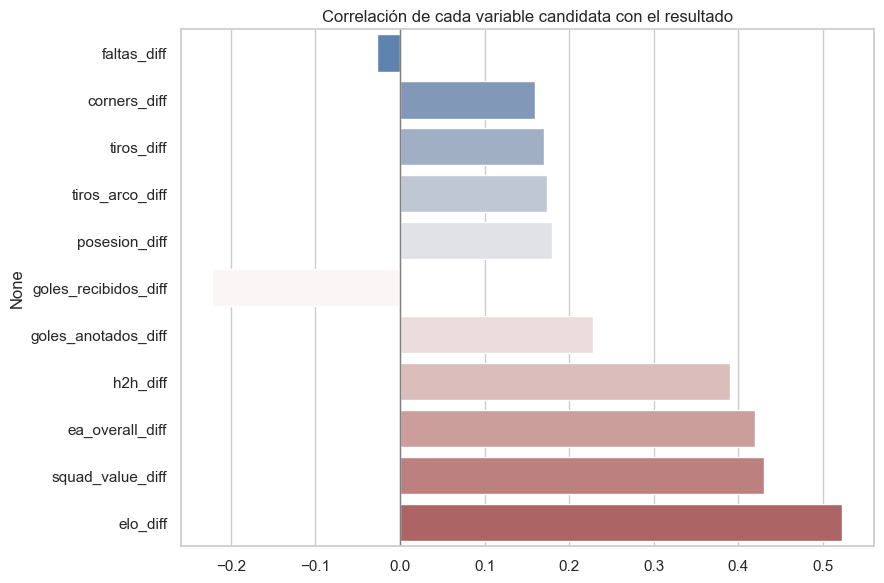

Mayor correlación: elo, valor de plantilla, EA y h2h. La forma (goles) aporta menos;
el estilo (tiros/posesión/córners) poco; las faltas, prácticamente nada.


In [3]:
cy = data[CAND].corrwith(data['resultado']).sort_values(key=abs)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=cy.values, y=cy.index, palette='vlag', ax=ax); ax.axvline(0, color='grey', lw=1)
ax.set_title('Correlación de cada variable candidata con el resultado'); plt.tight_layout(); plt.show()
print('Mayor correlación: elo, valor de plantilla, EA y h2h. La forma (goles) aporta menos;')
print('el estilo (tiros/posesión/córners) poco; las faltas, prácticamente nada.')

## 3 · Selección de variables (sin fuga) — el corazón del trabajo

Tres pasos, dejando que **los datos** decidan: **(A)** quitar redundantes por **VIF**, **(B)** quedarnos
con las que **mejoran la predicción** (forward por CV log-loss), **(C)** confirmar **significancia** (§5).

> ⚠️ **Dos fugas que evitamos.** *(i)* En las **features**: cada variable usa solo información previa al
> partido (point-in-time). *(ii)* En la **validación** — la mejora clave sobre la v4: el forward usa
> `TimeSeriesSplit` (entrenar en el pasado, validar en el bloque siguiente) y **solo con el train
> (<2025)**. Elegir variables mirando el test, o con CV barajada que mezcla futuro y pasado, es otra
> forma de mirar el futuro.

In [4]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

CORTE_TEST = '2025-01-01'
train = data[data.fecha < CORTE_TEST].reset_index(drop=True)   # la selección SOLO ve el train
y = train['resultado']
cv = TimeSeriesSplit(5)

def vifs(fs):
    X = sm.add_constant(train[fs])
    return {f: variance_inflation_factor(X.values, i + 1) for i, f in enumerate(fs)}

def ll(fs):
    p = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000))])
    return -cross_val_score(p, train[fs], y, cv=cv, scoring='neg_log_loss').mean()

# (A) VIF iterativo
feats = CAND[:]; print('(A) VIF iterativo (quito la peor hasta VIF<5):')
while True:
    v = vifs(feats); p = max(v, key=v.get)
    if v[p] < 5: break
    print(f'   quito {p} (VIF={v[p]:.1f})'); feats.remove(p)
if len(feats) == len(CAND):
    print(f'   ninguna eliminada — VIF máximo: {max(vifs(feats).values()):.1f} (las diffs no son colineales)')

# (B) forward por CV temporal
print('(B) Selección forward (log-loss, walk-forward CV):')
sel, rem, best = [], feats[:], 99
while rem:
    sc = {f: ll(sel + [f]) for f in rem}; bf = min(sc, key=sc.get)
    if sc[bf] < best - 0.001:
        sel.append(bf); rem.remove(bf); print(f'   + {bf:20} log-loss={sc[bf]:.4f}'); best = sc[bf]
    else:
        break
FINAL = sel
print(f'\n>>> SET FINAL (sin fuga): {FINAL}')
print(f'   log-loss con las 11 candidatas: {ll(CAND):.4f}  |  solo elo: {ll(["elo_diff"]):.4f}  |  set final: {ll(FINAL):.4f}')
print(f'   VIF del set final:', {k: round(v, 1) for k, v in vifs(FINAL).items()})

(A) VIF iterativo (quito la peor hasta VIF<5):
   ninguna eliminada — VIF máximo: 4.7 (las diffs no son colineales)
(B) Selección forward (log-loss, walk-forward CV):


   + elo_diff             log-loss=0.9115


   + h2h_diff             log-loss=0.9076
   + squad_value_diff     log-loss=0.9064



>>> SET FINAL (sin fuga): ['elo_diff', 'h2h_diff', 'squad_value_diff']
   log-loss con las 11 candidatas: 0.9160  |  solo elo: 0.9115  |  set final: 0.9064
   VIF del set final: {'elo_diff': 2.6, 'h2h_diff': 1.7, 'squad_value_diff': 2.1}


In [5]:
# RENDICIÓN DE CUENTAS: probamos agregar CADA candidata al set final
base = ll(FINAL)
Xv = sm.add_constant(train[CAND])
VIF = {f: variance_inflation_factor(Xv.values, i + 1) for i, f in enumerate(CAND)}
corr = train[CAND].corrwith(y); filas = []
for f in CAND:
    if f in FINAL:
        filas.append([f, round(corr[f], 2), round(VIF[f], 1), '—', '✅ seleccionada']); continue
    gain = base - ll(FINAL + [f])
    razon = 'VIF alto (colinealidad)' if VIF[f] > 5 else ('no mejora / mete ruido' if gain <= 0.001 else 'aporte mínimo')
    filas.append([f, round(corr[f], 2), round(VIF[f], 1), round(gain, 4), '❌ ' + razon])
display(pd.DataFrame(filas, columns=['variable', 'corr_target', 'VIF', 'mejora_log_loss', 'destino']))

,variable,corr_target,VIF,mejora_log_loss,destino
0,elo_diff,0.51,3.1,—,✅ seleccionada
1,squad_value_diff,0.41,4.4,—,✅ seleccionada
2,ea_overall_diff,0.40,4.7,-0.0008,❌ no mejora / mete ruido
3,h2h_diff,0.38,1.7,—,✅ seleccionada
4,goles_anotados_diff,0.22,1.2,-0.0008,❌ no mejora / mete ruido
5,goles_recibidos_diff,-0.22,1.2,-0.0004,❌ no mejora / mete ruido
6,tiros_diff,0.14,3.3,-0.0028,❌ no mejora / mete ruido
7,tiros_arco_diff,0.15,3.1,-0.0018,❌ no mejora / mete ruido
8,corners_diff,0.14,1.7,-0.0012,❌ no mejora / mete ruido
9,posesion_diff,0.17,1.4,-0.0044,❌ no mejora / mete ruido


**Resultado:** con validación temporal y solo el train, los datos eligen **3 variables**:
`elo_diff` (fuerza acumulada), `h2h_diff` (historia del cruce) y `squad_value_diff` (plantilla).

**Hallazgos clave:**
- 🔑 **El set final de 3 supera tanto al modelo de solo-Elo como al de las 11 candidatas completas** —
  la selección no es cosmética: las 8 variables descartadas *empeoran* la predicción (meten ruido).
- A diferencia de la v4, **ninguna variable cae por VIF**: las diferencias (local − visita) destilan
  bien y no son colineales entre sí (máx ≈ 4.7).
- El **`h2h_diff` ahora SÍ entra** (en la v4 quedaba tapado): con el Elo de base, la historia
  particular del cruce aporta señal extra — hay rivalidades que el rating general no captura.
- La **forma reciente no entra**: el Elo ya es un acumulador de forma (se actualiza partido a
  partido), así que los promedios móviles de goles son redundantes con él.
- Eco metodológico con la v4: de nuevo sobreviven **3 variables** y de la misma naturaleza —
  *fuerza + plantilla + algo más* (allá la forma, acá la historia del cruce).

### 3.1 · ¿Cuánta historia debe mirar el head-to-head?

El `h2h_diff` acumula **todos** los duelos directos desde 1872. Pregunta legítima: ¿tiene sentido que
un Brasil–Uruguay de 1950 pese igual que uno de 2024? ¿No habría que restringirlo a la última década?

En vez de decidirlo por intuición, lo sometemos al mismo protocolo: **recalculamos el h2h de cada
partido del train** con distintas ventanas — temporales (última década, últimos 20 años) y por número
de duelos (últimos 5, últimos 10) — y comparamos el set final con cada variante por walk-forward CV.
De paso, recalcular el h2h completo y compararlo con la columna del dataset sirve de **test de
reproducibilidad** del pipeline.

In [6]:
from collections import defaultdict

hist_h2h = pd.read_csv('../data/results.csv', parse_dates=['date']).dropna(subset=['home_score', 'away_score'])
idx_duelos = defaultdict(list)
for r in hist_h2h.sort_values('date').itertuples(index=False):
    k = (r.home_team, r.away_team) if r.home_team < r.away_team else (r.away_team, r.home_team)
    d = r.home_score - r.away_score if r.home_team == k[0] else r.away_score - r.home_score
    idx_duelos[k].append((r.date, d))   # d = dif. de gol desde la perspectiva de k[0]

def h2h_ventanas(a, b, fecha):
    k = (a, b) if a < b else (b, a)
    sgn = 1 if a == k[0] else -1
    prev = [(t, d) for t, d in idx_duelos[k] if t < fecha]
    var = {'completo (desde 1872)': prev,
           'últimos 20 años': [(t, d) for t, d in prev if t >= fecha - pd.DateOffset(years=20)],
           'última década': [(t, d) for t, d in prev if t >= fecha - pd.DateOffset(years=10)],
           'últimos 5 duelos': prev[-5:],
           'últimos 10 duelos': prev[-10:]}
    return {n: (sgn * float(np.mean([d for _, d in v])) if v else 0.0, len(v)) for n, v in var.items()}

vals = [h2h_ventanas(r.local, r.visita, r.fecha) for r in train.itertuples(index=False)]

# Test de reproducibilidad: el recálculo 'completo' debe coincidir con la columna del dataset
full_rec = np.array([v['completo (desde 1872)'][0] for v in vals])
err_max = np.abs(train.h2h_diff.values - full_rec.round(3)).max()
print(f'Reproducibilidad del pipeline: |h2h recalculado - columna del dataset| máx = {err_max:.4f}\n')

def ll_con_h2h(col):
    Xv = train[['elo_diff', 'squad_value_diff']].copy()
    if col is not None:
        Xv['h2h'] = col
    p = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000))])
    return -cross_val_score(p, Xv, y, cv=cv, scoring='neg_log_loss').mean()

filas = [{'variante de h2h': 'sin h2h', 'cobertura': '—', 'duelos prom.': '—', 'LogLoss CV': ll_con_h2h(None)}]
for n in vals[0]:
    col = np.array([v[n][0] for v in vals]); cnt = np.array([v[n][1] for v in vals])
    filas.append({'variante de h2h': n, 'cobertura': f'{(cnt > 0).mean():.1%}',
                  'duelos prom.': round(cnt.mean(), 1), 'LogLoss CV': ll_con_h2h(col)})
tabla_h2h = pd.DataFrame(filas).set_index('variante de h2h')
display(tabla_h2h.round(4).style.highlight_min(subset=['LogLoss CV'], color='lightgreen'))

Reproducibilidad del pipeline: |h2h recalculado - columna del dataset| máx = 0.0000



,cobertura,duelos prom.,LogLoss CV
variante de h2h,,,
sin h2h,—,—,0.909800
completo (desde 1872),87.4%,13.800000,0.906400
últimos 20 años,83.8%,5.100000,0.907200
última década,73.8%,2.600000,0.907000
últimos 5 duelos,87.4%,3.700000,0.906600
últimos 10 duelos,87.4%,6.000000,0.906100


**Veredicto:** la intuición de "solo la última década" **empeora** el modelo — no porque la historia
vieja sea valiosa en sí, sino por **cobertura**: las selecciones se cruzan poco (2.5 duelos promedio en
10 años) y la ventana corta deja a más de un cuarto de los partidos sin h2h. Las ventanas por *número
de duelos* (últimos 5 o 10) mantienen la cobertura y quedan **estadísticamente empatadas** con el
completo (diferencias de cuarta cifra decimal, muy por debajo de la variabilidad entre cortes de la
CV, ±0.04). Además, el promedio del h2h completo ya está naturalmente dominado por duelos recientes:
los pares que se enfrentan seguido lo refrescan solos.

**Decisión:** se mantiene el h2h completo del pipeline — cambiar la definición por una mejora
indistinguible del ruido no se justifica. El recálculo exacto (error 0.0000) queda como test de
reproducibilidad del dataset.

## 4 · División train/test y entrenamiento

**Split temporal**, no aleatorio: train = 2019–2024, test = **2025 → jun-2026** (~1,000 partidos que el
modelo jamás vio). La v4 usaba 75/25 estratificado al azar: eso mezcla partidos de 2026 en el train y
de 2022 en el test, inflando el rendimiento aparente. Aquí evaluamos al modelo **como se va a usar**:
entrenar con el pasado, predecir el futuro.

In [7]:
test = data[data.fecha >= CORTE_TEST].reset_index(drop=True)
Xtr, ytr = train[FINAL], train['resultado']
Xte, yte = test[FINAL], test['resultado']
pipe = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=2000))]).fit(Xtr, ytr)
print(f"Train: {len(Xtr):,} ({train.fecha.min().date()} -> {train.fecha.max().date()})")
print(f"Test : {len(Xte):,} ({test.fecha.min().date()} -> {test.fecha.max().date()})")
print(f"Variables: {FINAL}")

Train: 3,978 (2019-01-02 -> 2024-12-22)
Test : 1,045 (2025-01-04 -> 2026-06-09)
Variables: ['elo_diff', 'h2h_diff', 'squad_value_diff']


## 5 · Significancia (pseudo-R², p-values, coeficientes)

In [8]:
mn = sm.MNLogit(ytr.values, sm.add_constant(StandardScaler().fit_transform(Xtr))).fit(disp=0)
print(f'Pseudo-R² (McFadden) = {mn.prsquared:.3f}\n')
Pp, Pv = np.asarray(mn.params), np.asarray(mn.pvalues); nombres = ['const'] + FINAL
for k, clase in [(0, 'EMPATE vs Derrota'), (1, 'VICTORIA vs Derrota')]:
    t = pd.DataFrame({'variable': nombres, 'coef': Pp[:, k], 'p_value': Pv[:, k]})
    t['signif'] = np.where(t.p_value < 0.05, '✓', '')
    print(f'--- {clase} ---'); print(t.round(3).to_string(index=False)); print()

Pseudo-R² (McFadden) = 0.149

--- EMPATE vs Derrota ---
        variable  coef  p_value signif
           const 0.387    0.000      ✓
        elo_diff 0.756    0.000      ✓
        h2h_diff 0.176    0.008      ✓
squad_value_diff 0.093    0.164       

--- VICTORIA vs Derrota ---
        variable  coef  p_value signif
           const 0.653      0.0      ✓
        elo_diff 1.332      0.0      ✓
        h2h_diff 0.381      0.0      ✓
squad_value_diff 0.266      0.0      ✓



**Las 3 variables son significativas** (p<0.05) para la Victoria, con signos coherentes: más Elo,
mejor historia en el cruce y plantilla más valiosa → más probabilidad de ganar. Para el Empate los
coeficientes son menores (el empate es la clase "intermedia": depende menos de quién es mejor y más
de que el partido sea parejo).

## 6 · Matriz de confusión (test temporal 2025–26)

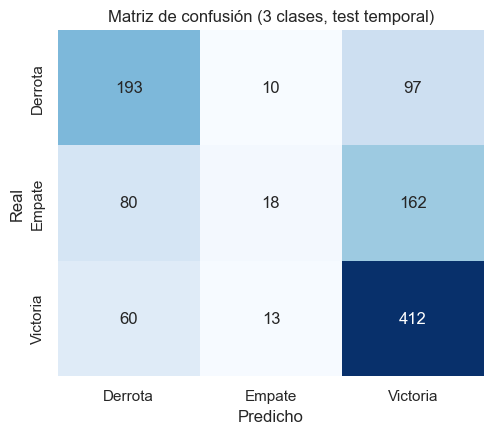

              precision    recall  f1-score   support

     Derrota       0.58      0.64      0.61       300
      Empate       0.44      0.07      0.12       260
    Victoria       0.61      0.85      0.71       485

    accuracy                           0.60      1045
   macro avg       0.54      0.52      0.48      1045
weighted avg       0.56      0.60      0.54      1045

Accuracy=0.596 | LogLoss=0.852


In [9]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, log_loss

pred = pipe.predict(Xte); proba = pipe.predict_proba(Xte)
cm = confusion_matrix(yte, pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Derrota', 'Empate', 'Victoria'], yticklabels=['Derrota', 'Empate', 'Victoria'])
ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title('Matriz de confusión (3 clases, test temporal)')
plt.show()
print(classification_report(yte, pred, labels=[0, 1, 2], target_names=['Derrota', 'Empate', 'Victoria']))
print(f'Accuracy={accuracy_score(yte, pred):.3f} | LogLoss={log_loss(yte, proba):.3f}')

El modelo acierta bien Victorias y Derrotas pero **casi nunca elige Empate por argmax** — la
siguiente sección explica por qué no es un error y cómo lo tratan los profesionales.

## 6b · Tratamiento del empate (cómo lo hacen los profesionales)

In [10]:
def rps(P, yv):
    Pc = np.cumsum(P, 1); Oc = np.cumsum(np.eye(3)[np.asarray(yv)], 1)
    return np.mean(np.sum((Pc - Oc) ** 2, 1)) / (3 - 1)

print(f'1) Calibración: P(empate) media={proba[:, 1].mean():.3f} vs tasa real={(yte == 1).mean():.3f}')
print(f'2) RPS (métrica profesional V/E/D) = {rps(proba, yte.values):.3f}  (menor=mejor)')
for w in [None, 'balanced']:
    mm = Pipeline([('sc', StandardScaler()),
                   ('m', LogisticRegression(max_iter=2000, class_weight=w))]).fit(Xtr, ytr)
    print(f'3) class_weight={str(w):9}: {(mm.predict(Xte) == 1).sum():3d} empates predichos | '
          f'LogLoss={log_loss(yte, mm.predict_proba(Xte)):.3f}')
print('   -> forzar empates (balanced) empeora el log-loss. El modelo ya da bien la PROBABILIDAD del empate.')

1) Calibración: P(empate) media=0.273 vs tasa real=0.249
2) RPS (métrica profesional V/E/D) = 0.162  (menor=mejor)
3) class_weight=None     :  41 empates predichos | LogLoss=0.852
3) class_weight=balanced : 273 empates predichos | LogLoss=0.880
   -> forzar empates (balanced) empeora el log-loss. El modelo ya da bien la PROBABILIDAD del empate.


Se evalúa con **RPS/log-loss** (no accuracy) y se usan las **probabilidades**, que es lo que
consume la simulación. El estándar de las casas de apuestas modela los goles (Poisson, sección 10).

## 6c · ¿Importa el tipo de partido? Amistosos vs partidos en serio

Hasta aquí tratamos cada partido por igual: un amistoso de verano pesa lo mismo que una final
continental. ¿Es eso un problema, dado que vamos a predecir partidos de **Mundial** (máxima
exigencia)? Una parte ya está cubierta — el **Elo descuenta los amistosos** vía su K-factor
(amistoso 20, clasificatoria 40, continental 50, Mundial 60) — pero el clasificador en sí trata
todas las filas igual. Lo medimos en vez de suponerlo.

In [11]:
def tipo_competicion(c):
    c = str(c).lower()
    if 'amistoso' in c: return 'amistoso'
    if 'clasif' in c: return 'clasificatoria'
    if 'nations league' in c: return 'nations_league'
    if 'mundial' in c: return 'mundial'
    return 'continental'   # AFCON, Euro, Copa América, Gold Cup...

K_FACTOR = {'amistoso': 1.0, 'clasificatoria': 2.0, 'nations_league': 2.0, 'continental': 2.5, 'mundial': 3.0}
data['tipo'] = data.competicion.map(tipo_competicion)
test_t = test.copy(); test_t['tipo'] = test_t.competicion.map(tipo_competicion)

# Desglose del log-loss del modelo base por tipo, en el TEST 2025-26
print('Log-loss del modelo en el test, desglosado por tipo de partido:')
filas = []
for t in ['clasificatoria', 'nations_league', 'continental', 'amistoso']:
    sub = test_t[test_t.tipo == t]
    if len(sub) < 20: continue
    P = pipe.predict_proba(sub[FINAL])
    filas.append({'tipo': t, 'n': len(sub), 'log_loss': log_loss(sub.resultado, P, labels=[0, 1, 2]),
                  'accuracy': accuracy_score(sub.resultado, P.argmax(1))})
comp = test_t[test_t.tipo != 'amistoso']; ami = test_t[test_t.tipo == 'amistoso']
filas.append({'tipo': 'TODO COMPETITIVO', 'n': len(comp),
              'log_loss': log_loss(comp.resultado, pipe.predict_proba(comp[FINAL]), labels=[0, 1, 2]),
              'accuracy': accuracy_score(comp.resultado, pipe.predict_proba(comp[FINAL]).argmax(1))})
filas.append({'tipo': 'TODO (titular)', 'n': len(test_t),
              'log_loss': log_loss(test_t.resultado, pipe.predict_proba(test_t[FINAL]), labels=[0, 1, 2]),
              'accuracy': accuracy_score(test_t.resultado, pipe.predict_proba(test_t[FINAL]).argmax(1))})
display(pd.DataFrame(filas).set_index('tipo').round(4))

Log-loss del modelo en el test, desglosado por tipo de partido:


,n,log_loss,accuracy
tipo,,,
clasificatoria,492,0.7648,0.6606
nations_league,28,1.0586,0.3214
amistoso,525,0.9221,0.5505
TODO COMPETITIVO,520,0.7806,0.6423
TODO (titular),1045,0.8517,0.5962


**Hallazgo 1 — los amistosos son genuinamente más impredecibles.** El modelo predice las
clasificatorias con log-loss ~0.76 pero los amistosos con ~0.92: en un amistoso se rota, se prueban
juveniles y la motivación es baja, así que el resultado es más azaroso. No es que el modelo "falle"
en ellos — es que *son* menos predecibles.

**Hallazgo 2 (la buena noticia) — nuestro pronóstico del Mundial es mejor de lo que dice el número
titular.** El 0.85 que reportamos como log-loss del modelo está *arrastrado hacia abajo* por los
amistosos (≈46% de la base). Pero el Mundial son partidos competitivos, y ahí el modelo rinde
**~0.78**. La métrica honestamente relevante para lo que nos importa es la del bloque competitivo.

In [12]:
# ¿Conviene entrenar distinto? Evaluamos sobre el test COMPETITIVO (proxy del Mundial).
def ll_estrategia(Xtr, ytr, w=None):
    p = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000))])
    p.fit(Xtr, ytr, m__sample_weight=w)
    return log_loss(comp.resultado, p.predict_proba(comp[FINAL]), labels=[0, 1, 2])

train_t = train.copy(); train_t['tipo'] = train_t.competicion.map(tipo_competicion)
tc = train_t[train_t.tipo != 'amistoso']
wk = train_t.tipo.map(K_FACTOR).values
estrategias = {
    'entrenar con TODO (actual)': ll_estrategia(train[FINAL], train.resultado),
    'entrenar SOLO competitivos': ll_estrategia(tc[FINAL], tc.resultado),
    'ponderar por K-factor (amist.1 → Mundial 3)': ll_estrategia(train[FINAL], train.resultado, w=wk),
}
print('Log-loss en el test COMPETITIVO según cómo se entrene:')
for k, v in estrategias.items():
    print(f'  {k:46}: {v:.4f}')

Log-loss en el test COMPETITIVO según cómo se entrene:
  entrenar con TODO (actual)                    : 0.7806
  entrenar SOLO competitivos                    : 0.7737
  ponderar por K-factor (amist.1 → Mundial 3)   : 0.7779


**Hallazgo 3 — inclinar el entrenamiento hacia partidos en serio ayuda, pero poco.** Tanto botar
los amistosos como ponderarlos a la baja mejora la predicción de partidos competitivos, de forma
consistente pero **dentro del ruido** (~0.005–0.007, por debajo del ±0.04 de variación entre cortes
de la CV). Agregar un *flag* de "es amistoso" como variable no ayuda (el Elo ya lo descuenta).

**Decisión:** para la simulación del torneo adoptamos la **ponderación por K-factor** — alinea el
clasificador con la misma filosofía del Elo (los partidos importan según su categoría) sin botar
datos, lo cual es más robusto para selecciones que casi solo juegan amistosos. Es una refinación
principista más que una mejora significativa; el grueso del mensaje es el Hallazgo 2: *el modelo
predice el Mundial mejor de lo que sugiere su métrica global*.

## 7 · ROC y calibración (clase Victoria)

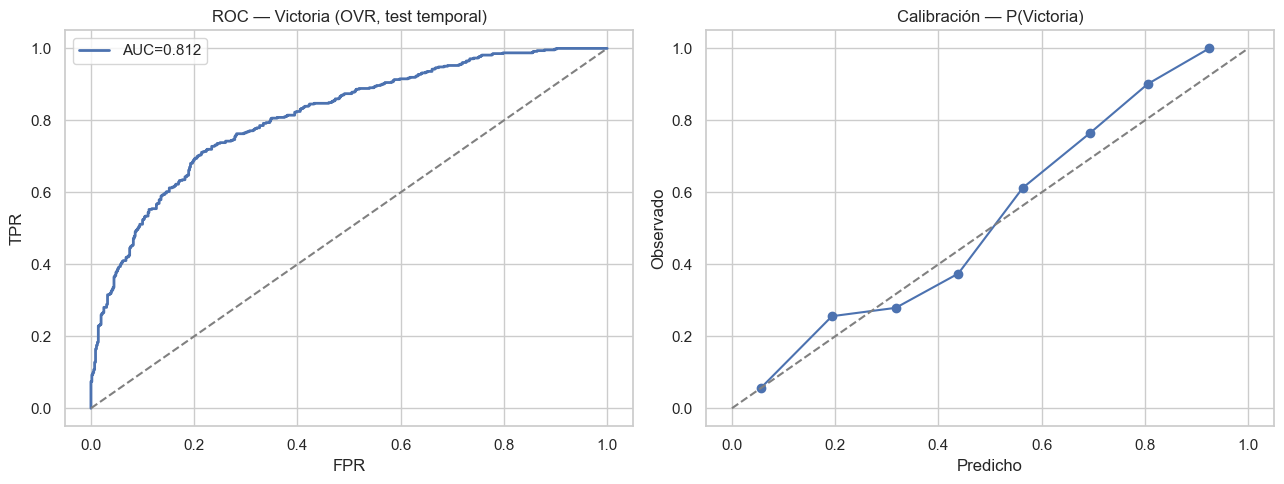

AUC (OVR macro) = 0.761


In [13]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.calibration import calibration_curve

yv = (yte == 2).astype(int); pv = proba[:, 2]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(yv, pv)
ax[0].plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr, tpr):.3f}'); ax[0].plot([0, 1], [0, 1], '--', color='grey')
ax[0].set_title('ROC — Victoria (OVR, test temporal)'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
po, pp_ = calibration_curve(yv, pv, n_bins=8)
ax[1].plot(pp_, po, 'o-'); ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_title('Calibración — P(Victoria)'); ax[1].set_xlabel('Predicho'); ax[1].set_ylabel('Observado')
plt.tight_layout(); plt.show()
print(f"AUC (OVR macro) = {roc_auc_score(yte, proba, multi_class='ovr', average='macro'):.3f}")

## 8 · Modelos alternativos (CV temporal, 5 cortes)

Dos filosofías frente a frente, bajo idéntico protocolo walk-forward sobre el train:

- **Selección manual** (sección 3): logística simple, interacciones, **SVM** (kernel RBF), **red
  neuronal (MLP)** y **logística ordinal** sobre el **set final** de 3 variables. Ni el SVM ni la red
  seleccionan variables por sí mismos, así que reciben el set ya destilado. La ordinal es la única de
  toda la tabla que **explota el orden natural de las clases** (derrota < empate < victoria): modela
  una sola dimensión latente de superioridad con dos umbrales, y el empate es la región intermedia.
  La probamos con sus **dos funciones de enlace** — *logit* y *probit* — para comprobar (y no asumir)
  que la elección del enlace es secundaria: solo difieren en las colas de la distribución.
- **Selección automática sobre las 11 candidatas**: **Lasso (L1)** elimina variables (coeficientes
  exactamente 0), **Ridge (L2)** las encoge sin eliminarlas, **Elastic Net** combina ambas
  penalizaciones (un `l1_ratio` controla la mezcla L1/L2), y los métodos de árboles (**Random Forest**,
  **Gradient Boosting** con *early stopping* y **XGBoost**, el boosting más usado en competencia)
  reparten importancia por sí solos. A estos modelos les damos las 11 *sin* filtrar — pasarles el set
  ya seleccionado sería redundante con su propio mecanismo.

**Ningún hiperparámetro va por defecto ni a ojo:** la fuerza de la penalización (`C`, `l1_ratio`), la
arquitectura del MLP y la profundidad/nº de árboles del XGBoost se eligen con el **mismo CV temporal**,
igual que hicimos con el forward. Referencias: **solo Elo** (1 variable) y la **logística con las 11
sin regularizar** (penalty=None).

In [14]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

def _logit(**kw):
    return LogisticRegression(max_iter=4000, **kw)

# Hiperparámetros por el mismo walk-forward (nada por defecto)
def cv_ll(model, fs):
    return -cross_val_score(model, train[fs], ytr, cv=cv, scoring='neg_log_loss').mean()

def mejor_C(penalty, solver='lbfgs'):
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=penalty, solver=solver, C=Cv))]), CAND)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0]}
    Cb = min(sc, key=sc.get)
    print(f'   {penalty.upper():4} sobre las 11 -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_elastic():
    sc = {(Cv, r): cv_ll(Pipeline([('sc', StandardScaler()),
                                   ('m', _logit(penalty='elasticnet', solver='saga', C=Cv, l1_ratio=r))]), CAND)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0] for r in [0.25, 0.5, 0.75]}
    (Cb, rb) = min(sc, key=sc.get)
    print(f'   ELASTIC NET sobre las 11 -> mejor C={Cb}, l1_ratio={rb} (log-loss {sc[(Cb, rb)]:.4f})')
    return Cb, rb

def mejor_C_svm():
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()),
                              ('m', SVC(kernel='rbf', C=Cv, probability=True, random_state=SEED))]), FINAL)
          for Cv in [0.3, 1, 3, 10]}
    Cb = min(sc, key=sc.get)
    print(f'   SVM RBF sobre el set final -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_xgb():
    sc = {}
    for d in [2, 3]:
        for n in [100, 300]:
            m = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, objective='multi:softprob', eval_metric='mlogloss',
                              random_state=SEED, n_jobs=-1, verbosity=0)
            sc[(d, n)] = cv_ll(m, CAND)
    (db, nb) = min(sc, key=sc.get)
    print(f'   XGBOOST sobre las 11 -> mejor depth={db}, n_estimators={nb} (log-loss {sc[(db, nb)]:.4f})')
    return db, nb

def mejor_mlp():
    sc = {}
    for h in [(8,), (16, 8)]:
        for a in [1e-3, 1e-2]:
            m = Pipeline([('sc', StandardScaler()),
                          ('m', MLPClassifier(hidden_layer_sizes=h, alpha=a, max_iter=2000,
                                              early_stopping=True, n_iter_no_change=20, random_state=SEED))])
            sc[(h, a)] = cv_ll(m, FINAL)
    (hb, ab) = min(sc, key=sc.get)
    print(f'   MLP sobre el set final -> mejor hidden={hb}, alpha={ab} (log-loss {sc[(hb, ab)]:.4f})')
    return hb, ab

print('Eligiendo hiperparámetros por CV temporal:')
C_l1 = mejor_C('l1', solver='saga')
C_l2 = mejor_C('l2')
C_en, r_en = mejor_elastic()
C_svm = mejor_C_svm()
d_xgb, n_xgb = mejor_xgb()
h_mlp, a_mlp = mejor_mlp()

mods = {
    'Logística (set final, forward)': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), FINAL),
    'Interacciones (set final)': (Pipeline([('sc', StandardScaler()),
                                            ('p', PolynomialFeatures(2, interaction_only=True, include_bias=False)),
                                            ('m', _logit())]), FINAL),
    f'SVM RBF (set final, C={C_svm})': (Pipeline([('sc', StandardScaler()),
                                                  ('m', SVC(kernel='rbf', C=C_svm, probability=True, random_state=SEED))]), FINAL),
    f'Lasso (las 11, C={C_l1})': (Pipeline([('sc', StandardScaler()),
                                            ('m', _logit(penalty='l1', solver='saga', C=C_l1))]), CAND),
    f'Ridge (las 11, C={C_l2})': (Pipeline([('sc', StandardScaler()),
                                            ('m', _logit(penalty='l2', C=C_l2))]), CAND),
    f'Elastic Net (las 11, C={C_en}, r={r_en})': (Pipeline([('sc', StandardScaler()),
                                                            ('m', _logit(penalty='elasticnet', solver='saga',
                                                                         C=C_en, l1_ratio=r_en))]), CAND),
    f'MLP {h_mlp} (set final)': (Pipeline([('sc', StandardScaler()),
                                           ('m', MLPClassifier(hidden_layer_sizes=h_mlp, alpha=a_mlp, max_iter=2000,
                                                               early_stopping=True, n_iter_no_change=20,
                                                               random_state=SEED))]), FINAL),
    'Random Forest (las 11)': (RandomForestClassifier(n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1), CAND),
    'Grad. Boosting (las 11, early stop)': (HistGradientBoostingClassifier(
        learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=40, max_iter=1000,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=25, random_state=SEED), CAND),
    f'XGBoost (las 11, depth={d_xgb}, n={n_xgb})': (XGBClassifier(
        n_estimators=n_xgb, max_depth=d_xgb, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0), CAND),
    'Ref: solo Elo': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), ['elo_diff']),
    'Ref: las 11 sin regularizar': (Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=None))]), CAND),
}

rps_scorer = make_scorer(lambda yv_, P: rps(P, yv_), response_method='predict_proba', greater_is_better=False)
res = []
for nom, (mod, fs) in mods.items():
    s = cross_validate(mod, train[fs], ytr, cv=cv, scoring={'acc': 'accuracy', 'll': 'neg_log_loss', 'rps': rps_scorer})
    res.append({'Modelo': nom, 'Accuracy': s['test_acc'].mean(),
                'LogLoss': -s['test_ll'].mean(), 'RPS': -s['test_rps'].mean()})

# ORDINAL en sus dos enlaces, logit y PROBIT (¿importa la función de enlace? — comprobémoslo
# en vez de asumirlo). statsmodels no es compatible con cross_validate -> mismo CV, loop manual.
from statsmodels.miscmodels.ordinal_model import OrderedModel
for distr, nombre_d in [('logit', 'Ordinal logit (set final)'), ('probit', 'Ordinal probit (set final)')]:
    lls, accs, rpss = [], [], []
    for tr_, va_ in cv.split(train):
        sc_ = StandardScaler().fit(train[FINAL].iloc[tr_])
        res_o = OrderedModel(ytr.values[tr_], sc_.transform(train[FINAL].iloc[tr_]), distr=distr).fit(method='bfgs', disp=0)
        P_o = np.asarray(res_o.predict(sc_.transform(train[FINAL].iloc[va_])))
        yva = ytr.values[va_]
        lls.append(log_loss(yva, P_o, labels=[0, 1, 2])); accs.append((P_o.argmax(1) == yva).mean()); rpss.append(rps(P_o, yva))
    res.append({'Modelo': nombre_d, 'Accuracy': np.mean(accs), 'LogLoss': np.mean(lls), 'RPS': np.mean(rpss)})

tabla = pd.DataFrame(res).set_index('Modelo').sort_values('LogLoss')
display(tabla.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen'))
best = next(n for n in tabla.index if n in mods)   # mejor modelo con API sklearn
MODEL_BEST, FEATS_BEST = mods[best]
print(f'>>> Mejor por CV temporal: {best} (variables: {FEATS_BEST})')
ev_test = MODEL_BEST.fit(train[FEATS_BEST], ytr)
P_best = ev_test.predict_proba(test[FEATS_BEST])
print(f'    En test 2025-26: LogLoss={log_loss(yte, P_best):.4f} | RPS={rps(P_best, yte.values):.4f} | '
      f'Accuracy={accuracy_score(yte, P_best.argmax(1)):.4f}')

Eligiendo hiperparámetros por CV temporal:


   L1   sobre las 11 -> mejor C=0.1 (log-loss 0.9129)
   L2   sobre las 11 -> mejor C=0.1 (log-loss 0.9158)


   ELASTIC NET sobre las 11 -> mejor C=0.1, l1_ratio=0.75 (log-loss 0.9133)


   SVM RBF sobre el set final -> mejor C=0.3 (log-loss 0.9441)


   XGBOOST sobre las 11 -> mejor depth=2, n_estimators=100 (log-loss 0.9254)


   MLP sobre el set final -> mejor hidden=(8,), alpha=0.01 (log-loss 0.9379)


,Accuracy,LogLoss,RPS
Modelo,,,
"Logística (set final, forward)",0.562600,0.906400,0.173400
Ordinal probit (set final),0.558100,0.906500,0.173600
Ordinal logit (set final),0.559900,0.907200,0.173600
Interacciones (set final),0.564100,0.908900,0.173800
Ref: solo Elo,0.563500,0.911500,0.174900
"Lasso (las 11, C=0.1)",0.561700,0.912900,0.174800
"Elastic Net (las 11, C=0.1, r=0.75)",0.559600,0.913300,0.174900
"Ridge (las 11, C=0.1)",0.556000,0.915800,0.175400
Ref: las 11 sin regularizar,0.556000,0.916100,0.175400


>>> Mejor por CV temporal: Logística (set final, forward) (variables: ['elo_diff', 'h2h_diff', 'squad_value_diff'])
    En test 2025-26: LogLoss=0.8517 | RPS=0.1616 | Accuracy=0.5962


In [15]:
# CAMINO DE REGULARIZACIÓN DEL LASSO: qué variables sobreviven a cada nivel de penalización.
# (C pequeño = penalización dura; C grande = suave). Nada de C "a ojo": el óptimo PREDICTIVO
# es el C elegido por CV arriba; el camino completo muestra el ORDEN en que caen las variables.
print('Camino de selección del Lasso sobre las 11 candidatas:')
for Cf in [0.002, 0.003, 0.005, 0.01, 0.03, 0.1, 0.3, 1.0]:
    m = Pipeline([('sc', StandardScaler()),
                  ('m', _logit(penalty='l1', solver='saga', C=Cf))]).fit(train[CAND], ytr)
    coefs = m.named_steps['m'].coef_
    vivas = [f for k, f in enumerate(CAND) if np.abs(coefs[:, k]).max() > 1e-8]
    caen = sorted(set(CAND) - set(vivas))
    detalle = ', '.join(vivas) if len(vivas) <= 4 else (
        'las 11' if not caen else f"todas menos: {', '.join(caen)}")
    marca = '   <<< C óptimo por CV (tabla)' if Cf == C_l1 else ''
    print(f'  C={Cf:<6} -> {len(vivas):2d} vivas: {detalle}{marca}')
print(f'\nForward (sección 3) había elegido: {FINAL}')

Camino de selección del Lasso sobre las 11 candidatas:
  C=0.002  ->  1 vivas: elo_diff
  C=0.003  ->  2 vivas: elo_diff, squad_value_diff
  C=0.005  ->  3 vivas: elo_diff, squad_value_diff, h2h_diff
  C=0.01   ->  3 vivas: elo_diff, squad_value_diff, h2h_diff
  C=0.03   ->  8 vivas: todas menos: ea_overall_diff, tiros_arco_diff, tiros_diff
  C=0.1    -> 10 vivas: todas menos: ea_overall_diff   <<< C óptimo por CV (tabla)
  C=0.3    -> 11 vivas: las 11
  C=1.0    -> 11 vivas: las 11

Forward (sección 3) había elegido: ['elo_diff', 'h2h_diff', 'squad_value_diff']


**Lectura.** Tres resultados:

1. **Convergencia de selecciones.** El camino del Lasso es un ranking de importancia: al endurecer la
   penalización, la última variable en morir es `elo_diff`, luego sobrevive con ella
   `squad_value_diff` y luego `h2h_diff` — **las 3 últimas supervivientes son exactamente las del
   forward, y en el mismo orden en que el forward las fue eligiendo**. Dos mecanismos de selección
   independientes (búsqueda secuencial por CV y penalización L1) llegan al mismo set: doble validación
   de la sección 3. Nótese también que lo primero que el Lasso descarta en su C óptimo es
   `ea_overall_diff` (redundante con Elo + plantilla).
2. **Seleccionar y luego ajustar gana a penalizar sin seleccionar.** Ni el mejor Lasso, ni el mejor
   Ridge, ni el **Elastic Net** (la combinación de ambas penalizaciones) sobre las 11 alcanzan al set
   final con logística simple: la regularización *encoge* el ruido de las 8 variables sobrantes pero
   no lo elimina del todo, y de paso encoge la señal de las buenas.
3. **La potencia bruta no paga en este problema.** Los tres métodos de árboles (Random Forest,
   Gradient Boosting, **XGBoost**) y la **red neuronal** quedan claramente detrás de las lineales: con
   ~4,000 partidos y una señal esencialmente monótona (más fuerza → más probabilidad de ganar), la
   flexibilidad extra solo encuentra ruido que memorizar. Los modelos **ordinales** — los
   *teóricamente* correctos para clases ordenadas — prácticamente empatan con la multinomial, y sus
   dos enlaces (**logit y probit**) difieren entre sí en la cuarta cifra decimal: la estructura
   ordinal es real pero la multinomial ya la captura (el empate no es solo "la región intermedia de
   fuerza" sino un fenómeno propio de partidos parejos), y la elección del enlace queda **comprobada
   como irrelevante** en este problema — probarlo costó una línea, asumirlo habría sido un acto de fe.
4. **El SVM paga su naturaleza.** Tiene una de las mejores *accuracy* de la tabla pero uno de los
   peores log-loss: optimiza el *margen* de clasificación, no probabilidades — las suyas salen de una
   calibración (Platt) posterior al entrenamiento. Como la simulación consume probabilidades, no nos
   sirve. Es el mejor ejemplo de por qué la métrica correcta aquí es log-loss/RPS y no accuracy.
   Las referencias cierran el cuadro: solo-Elo por detrás del set final (h2h y plantilla aportan), y
   las 11 sin regularizar al fondo de las lineales (el ruido cuesta).

## 9 · Simulación del Mundial 2026 (Monte Carlo)

El mejor modelo, re-entrenado con **todos** los datos (2019 → jun-2026), alimenta la simulación. Para
cada cruce reconstruimos las variables desde `team_states.csv` (estado al corte de junio 2026) y
`results.csv` (h2h histórico), **exactamente igual que en el entrenamiento**.

**Mejoras de la simulación sobre la v4:**
1. **Cancha neutral (simetrización):** el dataset arrastra ventaja de localía (44.6% gana el "local") que
   el modelo absorbe en sus interceptos. Como en el Mundial casi todo es neutral, predecimos cada cruce
   en **ambas orientaciones y promediamos** — la ventaja se cancela. Los **anfitriones** (USA, México,
   Canadá) conservan la orientación de local en **todas sus rondas**.
2. **Marcadores reales en grupos:** el resultado (V/E/D) lo sortea el clasificador y el marcador sale de
   una grilla de **Poisson condicionada a ese resultado** (la v4 usaba diferencia de gol ±1). Esto da
   desempates de grupo verosímiles (puntos → dif. de gol → goles → azar).
3. **Terceros bien rankeados:** los 8 mejores terceros se ordenan por puntos/dif. de gol/goles
   (la v4 los elegía al azar) y se asignan a las llaves permitidas por reglamento (matching bipartito).
4. **Ponderación por K-factor (§6c):** el modelo final se entrena dando más peso a los partidos
   competitivos (Mundial 3× un amistoso), para que el motor del torneo refleje cómo juegan las
   selecciones cuando se juegan algo — coherente con el Elo.

In [16]:
from sklearn.base import clone
from scipy.stats import poisson
from itertools import permutations

# Modelo definitivo: mejor configuración, entrenada con TODO (2019 -> jun-2026),
# ponderando por K-factor para que pesen más los partidos en serio (decisión de §6c).
from sklearn.pipeline import Pipeline as _Pipe
peso_kf = data.competicion.map(tipo_competicion).map(K_FACTOR).values
final_model = clone(MODEL_BEST)
_swkey = f'{final_model.steps[-1][0]}__sample_weight' if isinstance(final_model, _Pipe) else 'sample_weight'
final_model.fit(data[FEATS_BEST], data['resultado'], **{_swkey: peso_kf})

states = pd.read_csv('../data/team_states.csv').set_index('team')
hist = pd.read_csv('../data/results.csv', parse_dates=['date']).dropna(subset=['home_score', 'away_score'])

# Letras verificadas contra el calendario oficial del fixture (results.csv): México abre el
# Mundial en el Azteca el 11-jun (Grupo A), Canadá el 12-jun (B) y USA el 12-jun (D) — regla FIFA
# de anfitriones — y el resto por orden de primera aparición en el calendario (C 13-jun, E/F 14,
# G/H 15, I/J 16, K/L 17), consistente con el sorteo oficial de diciembre 2025.
GRUPOS = {
    'A': ['Czech Republic', 'Mexico', 'South Africa', 'South Korea'],
    'B': ['Bosnia and Herzegovina', 'Canada', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Haiti', 'Morocco', 'Scotland'],
    'D': ['Australia', 'Paraguay', 'Turkey', 'United States'],
    'E': ['Curaçao', 'Ecuador', 'Germany', 'Ivory Coast'],
    'F': ['Japan', 'Netherlands', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay'],
    'I': ['France', 'Iraq', 'Norway', 'Senegal'],
    'J': ['Algeria', 'Argentina', 'Austria', 'Jordan'],
    'K': ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
    'L': ['Croatia', 'England', 'Ghana', 'Panama'],
}
MUNDIALISTAS = [t for eqs in GRUPOS.values() for t in eqs]
ANFITRIONES = {'United States', 'Canada', 'Mexico'}

# Head-to-head histórico entre los 48 (idéntica semántica que el entrenamiento)
m48 = set(MUNDIALISTAS)
duelos = hist[hist.home_team.isin(m48) & hist.away_team.isin(m48)]
H2H = {}
for r in duelos.itertuples(index=False):
    d = r.home_score - r.away_score
    for a, b, s in ((r.home_team, r.away_team, d), (r.away_team, r.home_team, -d)):
        H2H.setdefault((a, b), []).append(s)
H2H = {k: float(np.mean(v)) for k, v in H2H.items()}


def features_cruce(a, b):
    '''Las 11 candidatas del cruce con `a` como local administrativo.'''
    sa, sb = states.loc[a], states.loc[b]
    return pd.DataFrame([{
        'elo_diff': sa.elo - sb.elo,
        'squad_value_diff': np.log(sa.squad_value) - np.log(sb.squad_value),
        'ea_overall_diff': sa.ea_overall - sb.ea_overall,
        'h2h_diff': H2H.get((a, b), 0.0),
        'goles_anotados_diff': sa.goles_anotados_avg - sb.goles_anotados_avg,
        'goles_recibidos_diff': sa.goles_recibidos_avg - sb.goles_recibidos_avg,
        'tiros_diff': sa.tiros_avg - sb.tiros_avg,
        'tiros_arco_diff': sa.tiros_arco_avg - sb.tiros_arco_avg,
        'corners_diff': sa.corners_avg - sb.corners_avg,
        'posesion_diff': sa.posesion_avg - sb.posesion_avg,
        'faltas_diff': sa.faltas_avg - sb.faltas_avg,
    }])


def prob_partido(a, b):
    '''[P(gana a), P(empate), P(gana b)] con simetrización; anfitriones conservan localía.'''
    pa = final_model.predict_proba(features_cruce(a, b)[FEATS_BEST])[0]   # clases [0=gana b, 1=emp, 2=gana a]
    pb = final_model.predict_proba(features_cruce(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])
    vb = np.array([pb[0], pb[1], pb[2]])
    if a in ANFITRIONES and b not in ANFITRIONES: return va
    if b in ANFITRIONES and a not in ANFITRIONES: return vb
    return (va + vb) / 2


# Poisson auxiliar (Elo -> goles esperados) SOLO para rellenar marcadores condicionados
espn = pd.read_csv('../data/espn_stats.csv', parse_dates=['fecha'])
espn = espn[(espn.fecha >= '2019-01-01') & espn.goles_local.notna()]
largo = pd.concat([
    pd.DataFrame({'g': espn.goles_local.values, 'd': (espn.elo_local - espn.elo_visita).values}),
    pd.DataFrame({'g': espn.goles_visita.values, 'd': (espn.elo_visita - espn.elo_local).values})])
gp = sm.GLM(largo['g'], sm.add_constant(largo[['d']]), family=sm.families.Poisson()).fit()
gb0, gb1 = gp.params['const'], gp.params['d']

def lambdas_elo(a, b):
    d = states.loc[a, 'elo'] - states.loc[b, 'elo']
    return float(np.exp(gb0 + gb1 * d)), float(np.exp(gb0 - gb1 * d))

p = prob_partido('Spain', 'Argentina')
print(f'Ejemplo — España vs Argentina (neutral): {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')
p = prob_partido('United States', 'Paraguay')
print(f'Ejemplo — USA (anfitrión) vs Paraguay  : {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')

Ejemplo — España vs Argentina (neutral): 37.8% / 32.8% / 29.4%
Ejemplo — USA (anfitrión) vs Paraguay  : 36.9% / 32.0% / 31.1%


### 9.1 · Partido a partido: los 72 partidos de la fase de grupos

El objetivo central del proyecto: probabilidades para **cada partido**. La tabla completa queda en
`predicciones_fase_grupos.csv`.

In [17]:
filas = []
for g, eqs in GRUPOS.items():
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = eqs[i], eqs[j]
            if b in ANFITRIONES and a not in ANFITRIONES:
                a, b = b, a
            p = prob_partido(a, b); la, lb = lambdas_elo(a, b)
            filas.append({'grupo': g, 'equipo_1': a, 'equipo_2': b,
                          'cancha': 'anfitrión' if (a in ANFITRIONES) ^ (b in ANFITRIONES) else 'neutral',
                          'P(gana 1)': round(p[0], 3), 'P(empate)': round(p[1], 3), 'P(gana 2)': round(p[2], 3),
                          'goles_esp_1': round(la, 2), 'goles_esp_2': round(lb, 2)})
pred_grupos = pd.DataFrame(filas)
pred_grupos.to_csv('../outputs/predicciones_fase_grupos.csv', index=False)
print('Guardado: predicciones_fase_grupos.csv (72 partidos)')
pred_grupos.head(12)

Guardado: predicciones_fase_grupos.csv (72 partidos)


,grupo,equipo_1,equipo_2,cancha,P(gana 1),P(empate),P(gana 2),goles_esp_1,goles_esp_2
0,A,Mexico,Czech Republic,anfitrión,0.500,0.325,0.176,1.57,0.78
1,A,Czech Republic,South Africa,neutral,0.519,0.300,0.180,1.46,0.84
2,A,Czech Republic,South Korea,neutral,0.324,0.329,0.347,0.96,1.28
3,A,Mexico,South Africa,anfitrión,0.737,0.208,0.054,2.06,0.59
4,A,Mexico,South Korea,anfitrión,0.521,0.305,0.174,1.36,0.90
5,A,South Africa,South Korea,neutral,0.141,0.280,0.579,0.73,1.69
6,B,Canada,Bosnia and Herzegovina,anfitrión,0.628,0.270,0.101,1.80,0.68
7,B,Bosnia and Herzegovina,Qatar,neutral,0.405,0.325,0.270,1.31,0.94
8,B,Bosnia and Herzegovina,Switzerland,neutral,0.152,0.286,0.562,0.62,1.97
9,B,Canada,Qatar,anfitrión,0.771,0.186,0.043,2.12,0.58


### 9.2 · Monte Carlo (10,000 mundiales, bracket oficial FIFA de 48)

In [18]:
rng = np.random.default_rng(SEED)
GRID_MAX = 10

# Bracket oficial: '1X'/'2X' = 1°/2° del grupo X; ('3', [...]) = mejor tercero permitido en esa llave.
R32 = {
    73: ('2A', '2B'), 74: ('1E', ('3', list('ABCDF'))), 75: ('1F', '2C'), 76: ('1C', '2F'),
    77: ('1I', ('3', list('CDFGH'))), 78: ('2E', '2I'), 79: ('1A', ('3', list('CEFHI'))),
    80: ('1L', ('3', list('EHIJK'))), 81: ('1D', ('3', list('BEFIJ'))), 82: ('1G', ('3', list('AEHIJ'))),
    83: ('2K', '2L'), 84: ('1H', '2J'), 85: ('1B', ('3', list('EFGIJ'))), 86: ('1J', '2H'),
    87: ('1K', ('3', list('DEIJL'))), 88: ('2D', '2G'),
}
R16 = {89: (74, 77), 90: (73, 75), 91: (76, 78), 92: (79, 80),
       93: (83, 84), 94: (81, 82), 95: (86, 88), 96: (85, 87)}
QF = {97: (89, 90), 98: (93, 94), 99: (91, 92), 100: (95, 96)}
SF = {101: (97, 98), 102: (99, 100)}
FINAL_M = (101, 102)


def asignar_terceros(grupos_terceros):
    '''Asigna los 8 terceros a los slots permitidos del bracket (matching bipartito máximo,
       algoritmo de Kuhn). Implementación determinista: mismo input -> misma asignación siempre.'''
    slots = {p: sorted(set(R32[p][1][1]) & grupos_terceros) for p in R32 if isinstance(R32[p][1], tuple)}
    asign, dueno = {}, {}   # slot -> grupo, grupo -> slot

    def intenta(p, visitados):
        for g in slots[p]:
            if g in visitados:
                continue
            visitados.add(g)
            if g not in dueno or intenta(dueno[g], visitados):
                dueno[g] = p; asign[p] = g
                return True
        return False

    for p in sorted(slots):
        intenta(p, set())
    for p in sorted(slots):                      # robustez: no debería ocurrir con las llaves FIFA
        if p not in asign:
            libres = sorted(set(grupos_terceros) - set(asign.values()))
            asign[p] = libres[0]
    return asign


# Precálculo: probabilidades y grillas de marcador condicionadas de los 2,256 cruces posibles
PROBS, SCORE_DIST = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    if (b, a) in PROBS:
        PROBS[(a, b)] = PROBS[(b, a)][::-1]
    else:
        PROBS[(a, b)] = prob_partido(a, b)
    la, lb = lambdas_elo(a, b)
    grid = np.outer(poisson.pmf(np.arange(GRID_MAX + 1), la), poisson.pmf(np.arange(GRID_MAX + 1), lb))
    grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    SCORE_DIST[(a, b)] = [np.cumsum((grid * mk).ravel() / (grid * mk).sum())
                          for mk in (gi > gj, gi == gj, gi < gj)]
print(f'Matriz de {len(PROBS):,} cruces lista. P(empate) media = {np.mean([v[1] for v in PROBS.values()]):.2f}')


def simular_partido(a, b, eliminatoria=False):
    p = PROBS[(a, b)]
    u = rng.random()
    res = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)   # 0=gana a, 1=empate, 2=gana b
    ga, gb = divmod(int(np.searchsorted(SCORE_DIST[(a, b)][res], rng.random())), GRID_MAX + 1)
    if res == 0: return ga, gb, a
    if res == 2: return ga, gb, b
    if eliminatoria:   # prórroga + penales en proporción a las prob. de victoria
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


def jugar_grupo(equipos, partido=simular_partido):
    pts = dict.fromkeys(equipos, 0); gf = dict.fromkeys(equipos, 0); gc = dict.fromkeys(equipos, 0)
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = partido(a, b)
            gf[a] += ga; gc[a] += gb; gf[b] += gb; gc[b] += ga
            if gan == a: pts[a] += 3
            elif gan == b: pts[b] += 3
            else: pts[a] += 1; pts[b] += 1
    return sorted(((t, pts[t], gf[t] - gc[t], gf[t], rng.random()) for t in equipos),
                  key=lambda x: (x[1], x[2], x[3], x[4]), reverse=True)


def jugar_mundial(partido=simular_partido):
    primeros, segundos, terceros = {}, {}, []
    for g, eqs in GRUPOS.items():
        tabla = jugar_grupo(eqs, partido)
        primeros[g], segundos[g] = tabla[0][0], tabla[1][0]
        t = tabla[2]
        terceros.append({'grupo': g, 'equipo': t[0], 'pts': t[1], 'gd': t[2], 'gf': t[3], 'rnd': t[4]})
    terceros.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
    tercero_por_grupo = {d['grupo']: d['equipo'] for d in terceros[:8]}
    asign = asignar_terceros(set(tercero_por_grupo))

    def slot(s, n):
        if isinstance(s, tuple): return tercero_por_grupo[asign[n]]
        return primeros[s[1]] if s[0] == '1' else segundos[s[1]]

    W = {}
    for n, (sa, sb) in R32.items():
        _, _, gan = partido(slot(sa, n), slot(sb, n), eliminatoria=True)
        W[n] = gan
    for ronda in (R16, QF, SF):
        for n, (p1, p2) in ronda.items():
            _, _, gan = partido(W[p1], W[p2], eliminatoria=True)
            W[n] = gan
    finalistas = (W[FINAL_M[0]], W[FINAL_M[1]])
    _, _, campeon = partido(*finalistas, eliminatoria=True)
    return {'campeon': campeon, 'finalistas': finalistas,
            'semifinalistas': [W[p] for p in (97, 98, 99, 100)],
            'a_octavos': [W[n] for n in R32]}


N_SIMS = 10000
cont = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial()
    cont[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont[t]['semi'] += 1
    for t in set(r['a_octavos']): cont[t]['octavos'] += 1

grupo_de = {t: g for g, eqs in GRUPOS.items() for t in eqs}
res_mc = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t], 'elo': round(states.loc[t, 'elo']),
                        'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                        'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                       for t, c in cont.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_mc.to_csv('../outputs/probabilidades_torneo.csv', index=False)
print(f'{N_SIMS:,} Mundiales simulados. Guardado: probabilidades_torneo.csv')
display(res_mc.head(12).style.format({'P_campeon': '{:.1%}', 'P_final': '{:.1%}', 'P_semi': '{:.1%}', 'P_octavos': '{:.1%}'}))

Matriz de 2,256 cruces lista. P(empate) media = 0.28


10,000 Mundiales simulados. Guardado: probabilidades_torneo.csv


,Selección,grupo,elo,P_campeon,P_final,P_semi,P_octavos
0,Spain,H,2223,29.2%,42.1%,55.4%,82.0%
1,Argentina,J,2189,18.9%,32.7%,47.1%,71.6%
2,France,I,2128,11.6%,21.2%,39.1%,78.1%
3,England,L,2090,9.1%,18.4%,32.0%,74.1%
4,Brazil,C,2069,7.3%,14.7%,29.4%,70.4%
5,Portugal,K,2056,4.2%,10.2%,20.2%,65.8%
6,Colombia,K,2064,3.2%,7.4%,15.3%,57.9%
7,Netherlands,F,2004,2.6%,6.5%,15.7%,52.3%
8,Germany,E,2000,2.5%,6.7%,17.4%,64.7%
9,Mexico,A,1985,1.8%,5.0%,13.8%,65.4%


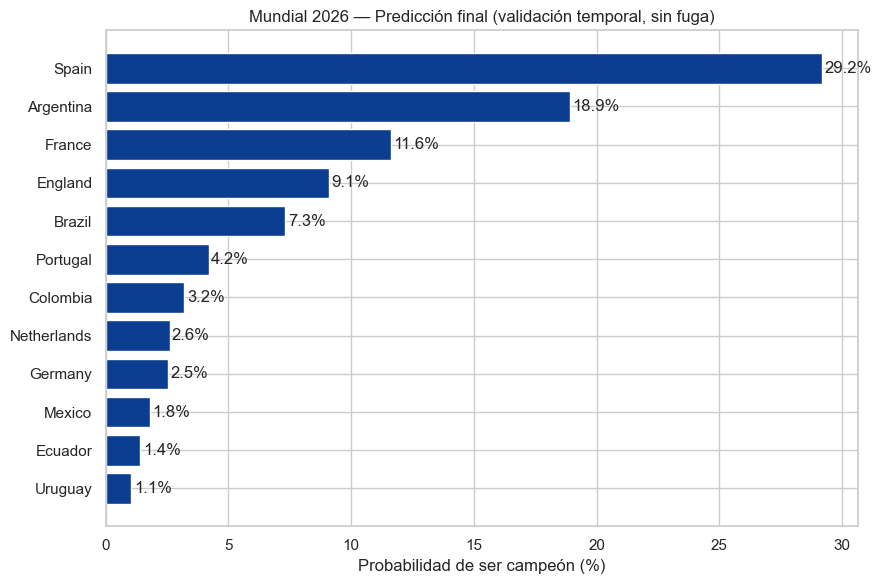

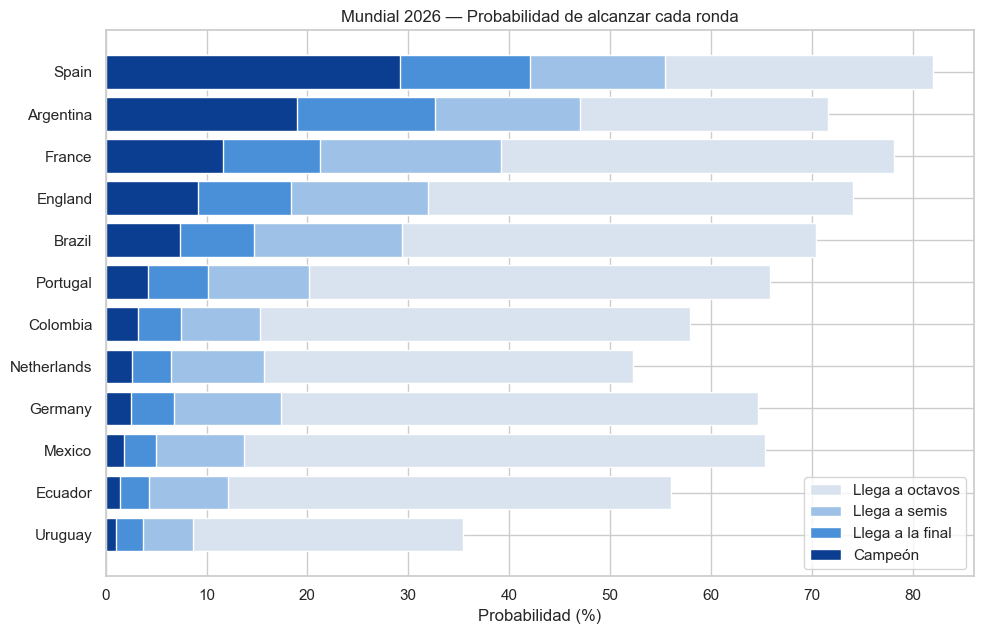

In [19]:
top = res_mc.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['Selección'], top.P_campeon * 100, color='#0b3d91')
for k, v in enumerate(top.P_campeon * 100):
    ax.text(v + 0.1, k, f'{v:.1f}%', va='center')
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 — Predicción final (validación temporal, sin fuga)')
plt.tight_layout(); plt.show()

t = res_mc.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(t['Selección'], t.P_octavos * 100, color='#d9e3f0', label='Llega a octavos')
ax.barh(t['Selección'], t.P_semi * 100, color='#9ec1e8', label='Llega a semis')
ax.barh(t['Selección'], t.P_final * 100, color='#4a90d9', label='Llega a la final')
ax.barh(t['Selección'], t.P_campeon * 100, color='#0b3d91', label='Campeón')
ax.set_xlabel('Probabilidad (%)'); ax.set_title('Mundial 2026 — Probabilidad de alcanzar cada ronda')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

### 9.3 · Un Mundial por dentro: tablas de grupo y bracket de una simulación

Las 10,000 corridas se resumen en probabilidades (§9.2), pero ¿cómo se ve **una**? Fijamos una semilla
y jugamos un Mundial completo con la misma maquinaria: las 12 tablas de grupo con puntos y goles
(PJ/Pts/GF/GC/DG), el ranking de los mejores terceros, y las eliminatorias ronda a ronda — con
marcador — hasta el campeón.

> ⚠️ Esto es **una realización** entre 10,000, NO el pronóstico (el pronóstico es la tabla de §9.2).
> Cambiar la semilla genera otro Mundial igual de plausible, y el campeón de una corrida individual
> puede perfectamente ser un tapado: el fútbol de eliminación directa es así de varianzudo — la celda
> final lo cuantifica con las propias 10,000 simulaciones. Esta sección sirve para *sentir* esa
> varianza, no para leerla como predicción.

In [20]:
rng = np.random.default_rng(2026)   # una realización concreta y reproducible

def jugar_grupo_detallado(equipos):
    st = {t: {'Pts': 0, 'PJ': 0, 'GF': 0, 'GC': 0} for t in equipos}
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = simular_partido(a, b)
            st[a]['PJ'] += 1; st[b]['PJ'] += 1
            st[a]['GF'] += ga; st[a]['GC'] += gb
            st[b]['GF'] += gb; st[b]['GC'] += ga
            if gan == a: st[a]['Pts'] += 3
            elif gan == b: st[b]['Pts'] += 3
            else: st[a]['Pts'] += 1; st[b]['Pts'] += 1
    orden = sorted(equipos, key=lambda t: (st[t]['Pts'], st[t]['GF'] - st[t]['GC'], st[t]['GF'], rng.random()),
                   reverse=True)
    return orden, st

primeros_d, segundos_d, terceros_d, filas = {}, {}, [], []
for g, eqs in GRUPOS.items():
    orden, st = jugar_grupo_detallado(eqs)
    primeros_d[g], segundos_d[g] = orden[0], orden[1]
    t3 = orden[2]
    terceros_d.append({'grupo': g, 'equipo': t3, 'pts': st[t3]['Pts'],
                       'gd': st[t3]['GF'] - st[t3]['GC'], 'gf': st[t3]['GF'], 'rnd': rng.random()})
    for pos, t in enumerate(orden, 1):
        filas.append({'Grupo': g, 'Pos': pos, 'Equipo': t, 'PJ': st[t]['PJ'], 'Pts': st[t]['Pts'],
                      'GF': st[t]['GF'], 'GC': st[t]['GC'], 'DG': st[t]['GF'] - st[t]['GC']})

tabla_grupos = pd.DataFrame(filas).set_index(['Grupo', 'Pos'])
display(tabla_grupos)

terceros_d.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
print('Ranking de terceros (clasifican los 8 primeros):')
for k, d in enumerate(terceros_d, 1):
    print(f"  {k:2d}. {d['equipo']:<24} (grupo {d['grupo']})  {d['pts']} pts, DG {d['gd']:+d}, "
          f"GF {d['gf']}  {'✅' if k <= 8 else '❌'}")
tercero_por_grupo_d = {d['grupo']: d['equipo'] for d in terceros_d[:8]}

Equipo  PJ  Pts  GF  GC  DG
Grupo Pos                                             
A     1               South Korea   3    5   5   2   3
      2            Czech Republic   3    5   4   2   2
      3                    Mexico   3    3   1   1   0
      4              South Africa   3    1   1   6  -5
B     1                    Canada   3    7   3   1   2
      2    Bosnia and Herzegovina   3    5   3   2   1
      3               Switzerland   3    4   4   2   2
      4                     Qatar   3    0   2   7  -5
C     1                   Morocco   3    7   5   1   4
      2                    Brazil   3    4   6   3   3
      3                  Scotland   3    4   2   3  -1
      4                     Haiti   3    1   2   8  -6
D     1                    Turkey   3    7   4   1   3
      2             United States   3    6   6   2   4
      3                  Paraguay   3    2   1   3  -2
      4                 Australia   3    1   1   6  -5
E     1                   Germany   3    9   7   1   6
      2                   Ecuador   3    6   7   4   3
      3               Ivory Coast   3    3   5   8  -3
      4                   Curaçao   3    0   2   8  -6
F     1               Netherlands   3    7   7   3   4
      2                   Tunisia   3    5   5   3   2
      3                    Sweden   3    2   4   6  -2
      4                     Japan   3    1   2   6  -4
G     1                   Belgium   3    3   3   3   0
      2               New Zealand   3    3   2   2   0
      3                     Egypt   3    3   1   1   0
      4                      Iran   3    3   0   0   0
H     1                     Spain   3    7   9   1   8
      2                   Uruguay   3    4   3   5  -2
      3              Saudi Arabia   3    2   2   5  -3
      4                Cape Verde   3    2   1   4  -3
I     1                    France   3    7   8   2   6
      2                   Senegal   3    4   2   3  -1
      3                    Norway   3    3   2   4  -2
      4                      Iraq   3    3   2   5  -3
J     1                   Algeria   3    7   5   1   4
      2                 Argentina   3    5   4   2   2
      3                   Austria   3    2   1   4  -3
      4                    Jordan   3    1   0   3  -3
K     1                Uzbekistan   3    7   3   1   2
      2                  Portugal   3    5   4   3   1
      3                  Colombia   3    4   4   3   1
      4                  DR Congo   3    0   0   4  -4
L     1                   Croatia   3    7   4   2   2
      2                   England   3    6   8   5   3
      3                     Ghana   3    3   3   4  -1
      4                    Panama   3    1   2   6  -4

Ranking de terceros (clasifican los 8 primeros):
   1. Switzerland              (grupo B)  4 pts, DG +2, GF 4  ✅
   2. Colombia                 (grupo K)  4 pts, DG +1, GF 4  ✅
   3. Scotland                 (grupo C)  4 pts, DG -1, GF 2  ✅
   4. Mexico                   (grupo A)  3 pts, DG +0, GF 1  ✅
   5. Egypt                    (grupo G)  3 pts, DG +0, GF 1  ✅
   6. Ghana                    (grupo L)  3 pts, DG -1, GF 3  ✅
   7. Norway                   (grupo I)  3 pts, DG -2, GF 2  ✅
   8. Ivory Coast              (grupo E)  3 pts, DG -3, GF 5  ✅
   9. Sweden                   (grupo F)  2 pts, DG -2, GF 4  ❌
  10. Paraguay                 (grupo D)  2 pts, DG -2, GF 1  ❌
  11. Saudi Arabia             (grupo H)  2 pts, DG -3, GF 2  ❌
  12. Austria                  (grupo J)  2 pts, DG -3, GF 1  ❌


In [21]:
asign_d = asignar_terceros(set(tercero_por_grupo_d))

def slot_d(s, n):
    if isinstance(s, tuple):
        return tercero_por_grupo_d[asign_d[n]]
    return primeros_d[s[1]] if s[0] == '1' else segundos_d[s[1]]

W = {}

def p_avance(a, b):
    '''P(a avanza en eliminatoria): victoria + empate resuelto por penales en proporción.'''
    p = PROBS[(a, b)]
    return p[0] + p[1] * p[0] / (p[0] + p[2])

def jugar_ronda_detallada(nombre, llaves, resolver):
    print(f'— {nombre} —')
    for n, (x, z) in llaves.items():
        a, b = resolver(x, n), resolver(z, n)
        ga, gb, gan = simular_partido(a, b, eliminatoria=True)
        pen = ' (penales)' if ga == gb else ''
        pgan = p_avance(a, b) if gan == a else 1 - p_avance(a, b)
        print(f'   {a:>24} {ga}-{gb} {b:<24}{pen} ->  {gan} (avanzaba con {pgan:.0%})')
        W[n] = gan
    print()

jugar_ronda_detallada('DIECISEISAVOS DE FINAL', R32, slot_d)
jugar_ronda_detallada('OCTAVOS DE FINAL', R16, lambda p, n: W[p])
jugar_ronda_detallada('CUARTOS DE FINAL', QF, lambda p, n: W[p])
jugar_ronda_detallada('SEMIFINALES', SF, lambda p, n: W[p])
fa, fb = W[FINAL_M[0]], W[FINAL_M[1]]
ga, gb, campeon = simular_partido(fa, fb, eliminatoria=True)
pen = ' (penales)' if ga == gb else ''
p_camp_final = p_avance(fa, fb) if campeon == fa else 1 - p_avance(fa, fb)
print(f'— FINAL —\n   {fa:>24} {ga}-{gb} {fb:<24}{pen} ->  {campeon} (ganaba la final con {p_camp_final:.0%})')
print(f'\n🏆 CAMPEÓN DEL MUNDIAL 2026 (en esta simulación): {campeon}')

p_camp = res_mc.set_index('Selección').loc[campeon, 'P_campeon']
top3 = res_mc.P_campeon.head(3).sum()
print(f'\nContexto: en las 10,000 simulaciones agregadas, {campeon} sale campeón el {p_camp:.1%} de las veces.')
print(f'Esta corrida es UNA historia posible — el pronóstico es la tabla de §9.2. De hecho, el campeón')
print(f'queda FUERA del top-3 de favoritos en ~{1 - top3:.0%} de los Mundiales simulados: así de abierto es el formato.')

— DIECISEISAVOS DE FINAL —
             Czech Republic 1-1 Bosnia and Herzegovina   (penales) ->  Czech Republic (avanzaba con 81%)
                    Germany 3-2 Mexico                   ->  Germany (avanzaba con 55%)
                Netherlands 0-1 Brazil                   ->  Brazil (avanzaba con 58%)
                    Morocco 2-0 Tunisia                  ->  Morocco (avanzaba con 83%)
                     France 1-0 Egypt                    ->  France (avanzaba con 96%)
                    Ecuador 1-0 Senegal                  ->  Ecuador (avanzaba con 59%)
                South Korea 0-3 Scotland                 ->  Scotland (avanzaba con 32%)
                    Croatia 2-0 Colombia                 ->  Croatia (avanzaba con 44%)
                     Turkey 1-1 Switzerland              (penales) ->  Turkey (avanzaba con 53%)
                    Belgium 0-0 Norway                   (penales) ->  Norway (avanzaba con 49%)
                   Portugal 0-3 England                  ->

#### ¿Y si siempre ganara el favorito? El bracket "sin azar"

Una intuición natural: ¿por qué no resolver cada partido por *mayoría* — que avance quien ganaría
más veces de 10,000? Probémoslo. Eso convierte la simulación en **un único bracket determinista**:
los grupos se ordenan por puntos esperados y en cada llave avanza el de mayor probabilidad.

El resultado es útil como referencia (es el *camino modal* del torneo), pero responde **otra
pregunta**: no puede repartir probabilidades — el favorito "gana" el 100% de las veces — y, como
muestra la última línea, la probabilidad de que el Mundial salga *exactamente* así es ínfima: hay que
multiplicar la probabilidad de cada uno de los 32 cruces, y hasta el favorito más claro tiene 60-80%
por partido. **El Mundial real será, con casi total seguridad, una de las historias "raras"** — por
eso el pronóstico se construye al revés: sorteando cada partido según su probabilidad y contando los
10,000 desenlaces.

In [22]:
# Grupos por puntos esperados (sin sorteo): E[pts] = 3*P(ganar) + 1*P(empatar)
def pts_esperados(eqs):
    ev = dict.fromkeys(eqs, 0.0)
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = eqs[i], eqs[j]
            p = PROBS[(a, b)]
            ev[a] += 3 * p[0] + p[1]; ev[b] += 3 * p[2] + p[1]
    return ev

primeros_f, segundos_f, terceros_f = {}, {}, []
for gl, eqs in GRUPOS.items():
    ev = pts_esperados(eqs)
    orden = sorted(eqs, key=lambda t: (ev[t], states.loc[t, 'elo']), reverse=True)
    primeros_f[gl], segundos_f[gl] = orden[0], orden[1]
    terceros_f.append((gl, orden[2], ev[orden[2]], states.loc[orden[2], 'elo']))

terceros_f.sort(key=lambda x: (x[2], x[3]), reverse=True)
tercero_g_f = {gl: t for gl, t, _, _ in terceros_f[:8]}
asign_f = asignar_terceros(set(tercero_g_f))

def slot_f(s, n):
    if isinstance(s, tuple): return tercero_g_f[asign_f[n]]
    return primeros_f[s[1]] if s[0] == '1' else segundos_f[s[1]]

Wf, prob_camino = {}, 1.0
for nombre, llaves, resolver in [('DIECISEISAVOS', R32, slot_f),
                                 ('OCTAVOS', R16, lambda x, n: Wf[x]),
                                 ('CUARTOS', QF, lambda x, n: Wf[x]),
                                 ('SEMIFINALES', SF, lambda x, n: Wf[x])]:
    print(f'— {nombre} —')
    for n, (x, z) in llaves.items():
        a, b = resolver(x, n), resolver(z, n)
        pav = p_avance(a, b)
        gan, pgan = (a, pav) if pav >= 0.5 else (b, 1 - pav)
        prob_camino *= pgan
        Wf[n] = gan
        print(f'   {a:>24} vs {b:<24} ->  {gan} ({pgan:.0%})')
    print()

fa_, fb_ = Wf[FINAL_M[0]], Wf[FINAL_M[1]]
pav = p_avance(fa_, fb_)
campeon_f, pgan = (fa_, pav) if pav >= 0.5 else (fb_, 1 - pav)
prob_camino *= pgan
print(f'— FINAL —\n   {fa_:>24} vs {fb_:<24} ->  {campeon_f} ({pgan:.0%})')
print(f'\n🏆 Campeón del bracket "sin azar": {campeon_f}')
print(f'\nProbabilidad de que las eliminatorias salgan EXACTAMENTE así: {prob_camino:.2e}')
print(f'   (~1 entre {1 / prob_camino:,.0f} — y eso sin contar la fase de grupos)')
print(f'P({campeon_f} campeón) según el Monte Carlo completo: '
      f"{res_mc.set_index('Selección').loc[campeon_f, 'P_campeon']:.1%} — esa es la lectura correcta.")

— DIECISEISAVOS —
                South Korea vs Switzerland              ->  Switzerland (64%)
                    Germany vs Czech Republic           ->  Germany (80%)
                Netherlands vs Morocco                  ->  Netherlands (56%)
                     Brazil vs Japan                    ->  Brazil (74%)
                     France vs Scotland                 ->  France (86%)
                    Ecuador vs Norway                   ->  Ecuador (54%)
                     Mexico vs Ivory Coast              ->  Mexico (86%)
                    England vs Algeria                  ->  England (79%)
                     Turkey vs Sweden                   ->  Turkey (74%)
                    Belgium vs Senegal                  ->  Belgium (56%)
                   Colombia vs Croatia                  ->  Colombia (56%)
                      Spain vs Austria                  ->  Spain (91%)
                     Canada vs Egypt                    ->  Canada (62%)
                  

### 9.4 · Simulador manual: arma tu propio *versus*

`versus(equipo1, equipo2)` enfrenta a **cualquier par de las 336 selecciones** de `team_states` (no
solo las 48 mundialistas — el head-to-head se calcula al vuelo desde `results.csv`) y entrega el
pronóstico completo: perfil del cruce, probabilidades V/E/D, probabilidad de avanzar en eliminatoria,
goles esperados, marcadores más probables, un resultado sorteado de ejemplo, y la **matriz de
marcadores** estilo casa de apuestas: cada celda es la probabilidad de ese marcador exacto según el
motor de la simulación (Poisson reponderada por el clasificador). El triángulo inferior es victoria
del primer equipo, la diagonal el empate y el superior la victoria del segundo; el marco **rojo**
marca el marcador más probable y el **verde punteado** el que salió sorteado en el ejemplo (las colas
de 6+ goles se agregan en la última fila/columna).

**Opciones de `cancha`:** `'auto'` (regla del Mundial: los anfitriones juegan de local, el resto
neutral), `'neutral'`, `'1'` (local el primer equipo) o `'2'` (local el segundo). Con `semilla=` fijas
el sorteo de ejemplo. Edita la última línea de la celda y re-ejecútala: `versus('France', 'Italy')`,
`versus('Peru', 'Chile', cancha='1')`, …

  Spain vs Argentina   —   cancha: neutral
Perfil del cruce (Spain − Argentina), las 3 variables del modelo:
   Elo               +34.2    (2223 vs 2189)
   Valor plantel     +0.40    (€1,279M vs €856M, escala log)
   Head-to-head      +0.07    (14 duelos previos desde 1872)

Probabilidades del clasificador (validado en 2025-26):
   Spain: 37.8%   |   Empate: 32.8%   |   Argentina: 29.4%
   Si es eliminatoria (prórroga/penales incl.): avanza Spain 56.2% / Argentina 43.8%

Goles esperados (Poisson): Spain 1.18 — 1.04 Argentina
Marcadores más probables (motor de la simulación):
   1-1 (15.1%)   1-0 (12.4%)   0-0 (12.3%)   0-1 (10.4%)   2-1 (7.6%)

🎲 Simulación de ejemplo: Spain 1-1 Argentina



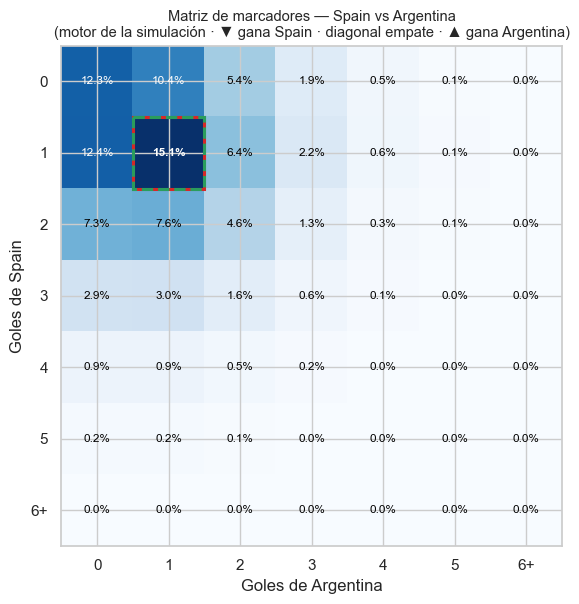

  Mexico vs Brazil   —   cancha: localía de Mexico (anfitrión del Mundial)
Perfil del cruce (Mexico − Brazil), las 3 variables del modelo:
   Elo               -84.1    (1985 vs 2069)
   Valor plantel     -2.35    (€111M vs €1,164M, escala log)
   Head-to-head      -0.95    (42 duelos previos desde 1872)

Probabilidades del clasificador (validado en 2025-26):
   Mexico: 23.7%   |   Empate: 33.0%   |   Brazil: 43.2%
   Si es eliminatoria (prórroga/penales incl.): avanza Mexico 35.4% / Brazil 64.6%

Goles esperados (Poisson): Mexico 0.94 — 1.30 Brazil
Marcadores más probables (motor de la simulación):
   1-1 (15.2%)   0-1 (13.3%)   0-0 (12.4%)   1-0 (8.8%)   0-2 (8.7%)

🎲 Simulación de ejemplo: Mexico 1-0 Brazil



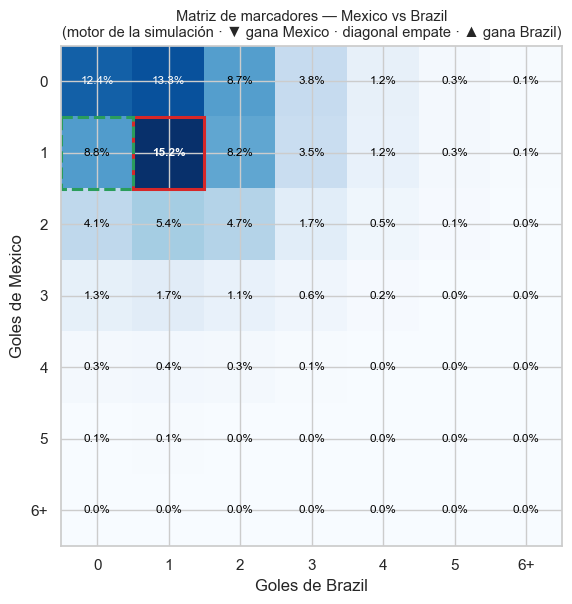

  Chile vs Argentina   —   cancha: localía de Chile
Perfil del cruce (Chile − Argentina), las 3 variables del modelo:
   Elo              -395.6    (1794 vs 2189)
   Valor plantel     -2.43    (€75M vs €856M, escala log)
   Head-to-head      -1.26    (91 duelos previos desde 1872)

Probabilidades del clasificador (validado en 2025-26):
   Chile: 6.8%   |   Empate: 21.0%   |   Argentina: 72.3%
   Si es eliminatoria (prórroga/penales incl.): avanza Chile 8.6% / Argentina 91.4%

Goles esperados (Poisson): Chile 0.52 — 2.38 Argentina
Marcadores más probables (motor de la simulación):
   0-2 (14.3%)   0-1 (12.1%)   0-3 (11.4%)   1-1 (9.7%)   0-0 (7.9%)

🎲 Simulación de ejemplo: Chile 0-3 Argentina



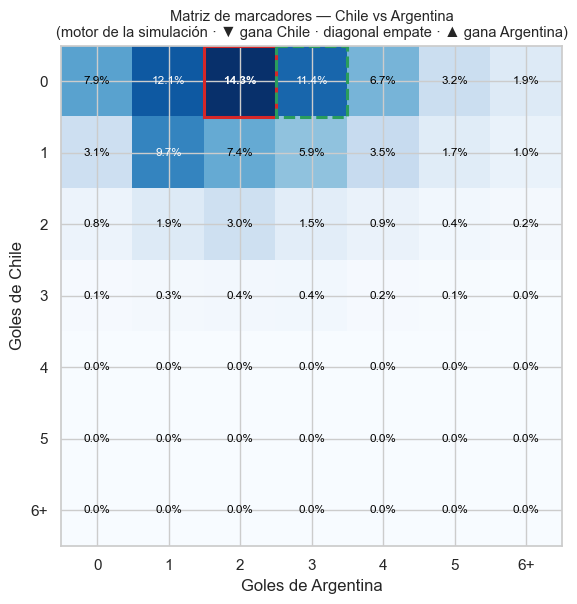

In [23]:
def h2h_par(a, b):
    '''H2H histórico para cualquier par: (promedio de dif. de gol desde la perspectiva de a, nº duelos).'''
    mm = hist[((hist.home_team == a) & (hist.away_team == b)) | ((hist.home_team == b) & (hist.away_team == a))]
    if len(mm) == 0:
        return 0.0, 0
    d = np.where(mm.home_team == a, mm.home_score - mm.away_score, mm.away_score - mm.home_score)
    return float(d.mean()), int(len(mm))


def _features_par(a, b):
    '''Las 11 candidatas para cualquier par de selecciones (h2h al vuelo, sirve fuera de los 48).'''
    sa, sb = states.loc[a], states.loc[b]
    return pd.DataFrame([{
        'elo_diff': sa.elo - sb.elo,
        'squad_value_diff': np.log(sa.squad_value) - np.log(sb.squad_value),
        'ea_overall_diff': sa.ea_overall - sb.ea_overall,
        'h2h_diff': h2h_par(a, b)[0],
        'goles_anotados_diff': sa.goles_anotados_avg - sb.goles_anotados_avg,
        'goles_recibidos_diff': sa.goles_recibidos_avg - sb.goles_recibidos_avg,
        'tiros_diff': sa.tiros_avg - sb.tiros_avg,
        'tiros_arco_diff': sa.tiros_arco_avg - sb.tiros_arco_avg,
        'corners_diff': sa.corners_avg - sb.corners_avg,
        'posesion_diff': sa.posesion_avg - sb.posesion_avg,
        'faltas_diff': sa.faltas_avg - sb.faltas_avg,
    }])


def versus(equipo1, equipo2, cancha='auto', semilla=None, matriz=True):
    '''Pronóstico detallado de un partido entre dos selecciones cualquiera.
       cancha: 'auto' | 'neutral' | '1' (local el 1°) | '2' (local el 2°).
       matriz: si True, dibuja la matriz de probabilidad de cada marcador exacto.'''
    for t in (equipo1, equipo2):
        if t not in states.index:
            parecidos = [s for s in states.index if t.lower() in s.lower()][:5]
            raise ValueError(f"'{t}' no está en team_states. ¿Quizás quisiste decir: {parecidos}?")
    a, b = equipo1, equipo2
    pa = final_model.predict_proba(_features_par(a, b)[FEATS_BEST])[0]
    pb = final_model.predict_proba(_features_par(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])   # perspectiva: [gana a, empate, gana b]
    vb = np.array([pb[0], pb[1], pb[2]])
    if cancha == '1':
        p, desc = va, f'localía de {a}'
    elif cancha == '2':
        p, desc = vb, f'localía de {b}'
    elif cancha == 'auto' and a in ANFITRIONES and b not in ANFITRIONES:
        p, desc = va, f'localía de {a} (anfitrión del Mundial)'
    elif cancha == 'auto' and b in ANFITRIONES and a not in ANFITRIONES:
        p, desc = vb, f'localía de {b} (anfitrión del Mundial)'
    else:
        p, desc = (va + vb) / 2, 'neutral'

    la, lb = lambdas_elo(a, b)
    g = np.arange(GRID_MAX + 1)
    grid = np.outer(poisson.pmf(g, la), poisson.pmf(g, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    masks = (gi > gj, gi == gj, gi < gj)
    mix = sum(p[k] * (grid * mk) / (grid * mk).sum() for k, mk in enumerate(masks))

    sa, sb = states.loc[a], states.loc[b]
    h2h_v, n_duelos = h2h_par(a, b)
    print('=' * 66)
    print(f'  {a} vs {b}   —   cancha: {desc}')
    print('=' * 66)
    print(f'Perfil del cruce ({a} − {b}), las 3 variables del modelo:')
    print(f'   Elo            {sa.elo - sb.elo:+8.1f}    ({sa.elo:.0f} vs {sb.elo:.0f})')
    print(f'   Valor plantel  {np.log(sa.squad_value) - np.log(sb.squad_value):+8.2f}    '
          f'(€{sa.squad_value / 1e6:,.0f}M vs €{sb.squad_value / 1e6:,.0f}M, escala log)')
    print(f'   Head-to-head   {h2h_v:+8.2f}    ({n_duelos} duelos previos desde 1872)')
    print(f'\nProbabilidades del clasificador (validado en 2025-26):')
    print(f'   {a}: {p[0]:.1%}   |   Empate: {p[1]:.1%}   |   {b}: {p[2]:.1%}')
    pkA = p[0] + p[1] * p[0] / (p[0] + p[2])
    print(f'   Si es eliminatoria (prórroga/penales incl.): avanza {a} {pkA:.1%} / {b} {1 - pkA:.1%}')
    print(f'\nGoles esperados (Poisson): {a} {la:.2f} — {lb:.2f} {b}')
    flat = mix.ravel(); top = flat.argsort()[::-1][:5]
    print('Marcadores más probables (motor de la simulación):')
    print('   ' + '   '.join(f'{ix // (GRID_MAX + 1)}-{ix % (GRID_MAX + 1)} ({flat[ix]:.1%})' for ix in top))
    r = np.random.default_rng(semilla) if semilla is not None else rng
    u = r.random(); resu = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)
    cond = (grid * masks[resu]).ravel(); cond = cond / cond.sum()
    ga_, gb_ = divmod(int(np.searchsorted(np.cumsum(cond), r.random())), GRID_MAX + 1)
    print(f'\n🎲 Simulación de ejemplo: {a} {ga_}-{gb_} {b}\n')

    if matriz:
        m = 6   # mostramos 0..5 y agregamos las colas en '6+'
        M = np.zeros((m + 1, m + 1))
        M[:m, :m] = mix[:m, :m]
        M[m, :m] = mix[m:, :m].sum(axis=0)
        M[:m, m] = mix[:m, m:].sum(axis=1)
        M[m, m] = mix[m:, m:].sum()
        fig, ax = plt.subplots(figsize=(7.4, 6.2))
        ax.imshow(M, cmap='Blues')
        etiq = [str(i) for i in range(m)] + ['6+']
        ax.set_xticks(range(m + 1)); ax.set_xticklabels(etiq)
        ax.set_yticks(range(m + 1)); ax.set_yticklabels(etiq)
        ax.set_xlabel(f'Goles de {b}'); ax.set_ylabel(f'Goles de {a}')
        ax.set_title(f'Matriz de marcadores — {a} vs {b}\n'
                     f'(motor de la simulación · ▼ gana {a} · diagonal empate · ▲ gana {b})', fontsize=10.5)
        imax, jmax = np.unravel_index(M.argmax(), M.shape)
        for i in range(m + 1):
            for j in range(m + 1):
                ax.text(j, i, f'{M[i, j]:.1%}', ha='center', va='center', fontsize=8.5,
                        color='white' if M[i, j] > M.max() * 0.6 else 'black',
                        fontweight='bold' if (i, j) == (imax, jmax) else 'normal')
        # rojo = marcador más probable; verde punteado = el sorteado en la simulación de ejemplo
        ax.add_patch(plt.Rectangle((jmax - 0.5, imax - 0.5), 1, 1, fill=False, edgecolor='#d62728', lw=2.2))
        ax.add_patch(plt.Rectangle((min(gb_, m) - 0.5, min(ga_, m) - 0.5), 1, 1,
                                   fill=False, edgecolor='#2a9d5c', lw=2.2, ls='--'))
        plt.tight_layout(); plt.show()


versus('Spain', 'Argentina')
versus('Mexico', 'Brazil')                  # anfitrión -> localía automática
versus('Chile', 'Argentina', cancha='1')    # también sirve para selecciones fuera del Mundial

## 10 · Modelo Poisson de goles (enfoque casas de apuestas)

El estándar profesional modela los **goles** (Poisson) y deriva V/E/D de la grilla de marcadores; los
empates surgen naturalmente y permite predecir el **marcador exacto**. Lo ajustamos con las **mismas 3
variables del set final** (dos observaciones por partido, una por equipo, con los deltas con signo
invertido para el visitante), entrenando en 2019–24 y comparando contra la multinomial en el **mismo
test temporal**.

In [24]:
# Goles reales de cada partido (merge 1:1 con espn_stats por fecha+equipos)
goles = pd.read_csv('../data/espn_stats.csv', parse_dates=['fecha'])[['fecha', 'local', 'visita', 'goles_local', 'goles_visita']]
datag = data.merge(goles, on=['fecha', 'local', 'visita'], how='left')
dtr = datag[datag.fecha < CORTE_TEST]; dte = datag[datag.fecha >= CORTE_TEST]

largo_tr = pd.concat([
    dtr[FINAL].assign(g=dtr.goles_local.values),
    (-dtr[FINAL]).assign(g=dtr.goles_visita.values)], ignore_index=True)
pois = sm.GLM(largo_tr['g'], sm.add_constant(largo_tr[FINAL]), family=sm.families.Poisson()).fit()
b0 = pois.params['const']; bet = pois.params[FINAL].values
print(pois.summary().tables[1])

def lambdas_final(fr):
    s = float(np.dot(bet, fr)); return np.exp(b0 + s), np.exp(b0 - s)

def wdl(li, lj, m=10):
    # filas = goles del local (i), columnas = goles de la visita (j)
    Mx = np.outer(poisson.pmf(np.arange(m + 1), li), poisson.pmf(np.arange(m + 1), lj))
    return np.array([np.triu(Mx, 1).sum(), np.trace(Mx), np.tril(Mx, -1).sum()])   # [derrota (j>i), empate, victoria (i>j)]

pp = np.array([wdl(*lambdas_final(r)) for r in dte[FINAL].values])
pp /= pp.sum(1, keepdims=True)
pl = pipe.predict_proba(dte[FINAL]); yv_ = dte.resultado.values
pe = (pl + pp) / 2   # ensamble: promedio de las probabilidades de ambas familias
comp = pd.DataFrame({'Modelo': ['Logística multinomial', 'Poisson de goles', 'Ensamble (promedio de ambos)'],
                     'Accuracy': [accuracy_score(yv_, P.argmax(1)) for P in (pl, pp, pe)],
                     'LogLoss': [log_loss(yv_, P) for P in (pl, pp, pe)],
                     'RPS': [rps(P, yv_) for P in (pl, pp, pe)]}).set_index('Modelo')
display(comp.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen'))

print('Marcadores más probables (Poisson, estado actual de los equipos):')
for i, j in [('Spain', 'Argentina'), ('France', 'Brazil'), ('England', 'Germany')]:
    fr = features_cruce(i, j)[FINAL].values[0]
    li, lj = lambdas_final(fr)
    m = np.outer(poisson.pmf(np.arange(7), li), poisson.pmf(np.arange(7), lj))
    x, y_ = np.unravel_index(m.argmax(), m.shape)
    print(f'  {i} {x}-{y_} {j}  ({m[x, y_] * 100:.0f}% el marcador, λ: {li:.2f} - {lj:.2f})')

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0801      0.011      7.097      0.000       0.058       0.102
elo_diff             0.0016   5.94e-05     27.348      0.000       0.002       0.002
h2h_diff             0.0657      0.008      8.607      0.000       0.051       0.081
squad_value_diff     0.0144      0.006      2.265      0.023       0.002       0.027


,Accuracy,LogLoss,RPS
Modelo,,,
Logística multinomial,0.596200,0.851700,0.161600
Poisson de goles,0.598100,0.860400,0.164100
Ensamble (promedio de ambos),0.598100,0.852300,0.162100


Marcadores más probables (Poisson, estado actual de los equipos):
  Spain 1-1 Argentina  (13% el marcador, λ: 1.16 - 1.01)
  France 1-1 Brazil  (13% el marcador, λ: 1.17 - 1.01)
  England 1-0 Germany  (14% el marcador, λ: 1.28 - 0.91)


Ambos enfoques quedan en niveles muy parecidos de log-loss/RPS — **dos familias de modelos
distintas llegan a las mismas probabilidades**, señal de que la información de las variables está bien
explotada y el resto es la varianza propia del fútbol. El **ensamble** (promediar las probabilidades
de ambos) tampoco mejora a la multinomial sola — cuando dos modelos coinciden, promediarlos no agrega
información nueva. Usamos la multinomial para el V/E/D (es la validada en §4-8) y la Poisson como
generadora de marcadores en la simulación.

### 10.1 · El Mundial según la Poisson: misma simulación, otro motor

Si la Poisson ve los partidos casi igual que la multinomial, ¿predice el mismo Mundial? Lo
comprobamos de la forma más directa: **re-simulamos el torneo completo 10,000 veces** usando la
Poisson como único motor — los goles de cada partido se sortean directamente de
$\text{Pois}(\lambda_a), \text{Pois}(\lambda_b)$ con las mismas 3 variables, mismo bracket, mismos
desempates (re-entrenada con todos los datos, igual que el clasificador).

Dos diferencias estructurales a tener presentes: la Poisson se entrenó **simétrica** (sin término de
localía, así que los anfitriones no reciben ventaja aquí), y con goles independientes tiende a
repartir **menos empates** que el clasificador.

In [25]:
# Poisson definitiva (TODOS los datos) y grillas por cruce
largo_full = pd.concat([
    datag[FINAL].assign(g=datag.goles_local.values),
    (-datag[FINAL]).assign(g=datag.goles_visita.values)], ignore_index=True)
pois_full = sm.GLM(largo_full['g'], sm.add_constant(largo_full[FINAL]), family=sm.families.Poisson()).fit()
b0f = pois_full.params['const']; betf = pois_full.params[FINAL].values

gidx = np.arange(GRID_MAX + 1)
PROBS_P, SCORE_P = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    fr = features_cruce(a, b)[FINAL].values[0].astype(float)
    s = float(np.dot(betf, fr))
    la, lb = np.exp(b0f + s), np.exp(b0f - s)
    grid = np.outer(poisson.pmf(gidx, la), poisson.pmf(gidx, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    PROBS_P[(a, b)] = np.array([(grid * (gi > gj)).sum(), np.trace(grid), (grid * (gi < gj)).sum()])
    SCORE_P[(a, b)] = np.cumsum(grid.ravel())


def simular_partido_poisson(a, b, eliminatoria=False):
    '''Motor Poisson puro: el marcador se sortea de la grilla; el V/E/D emerge de los goles.'''
    ga, gb = divmod(int(np.searchsorted(SCORE_P[(a, b)], rng.random())), GRID_MAX + 1)
    if ga > gb: return ga, gb, a
    if gb > ga: return ga, gb, b
    if eliminatoria:
        p = PROBS_P[(a, b)]
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


rng = np.random.default_rng(SEED)   # misma semilla que el Monte Carlo del clasificador
cont_p = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial(partido=simular_partido_poisson)
    cont_p[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont_p[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont_p[t]['semi'] += 1
    for t in set(r['a_octavos']): cont_p[t]['octavos'] += 1

res_pois = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t],
                          'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                          'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                         for t, c in cont_p.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_pois.to_csv('../outputs/probabilidades_torneo_poisson.csv', index=False)
print(f'{N_SIMS:,} Mundiales simulados con motor Poisson. Guardado: probabilidades_torneo_poisson.csv\n')
res_pois.head(12).style.format({'P_campeon': '{:.1%}', 'P_final': '{:.1%}', 'P_semi': '{:.1%}', 'P_octavos': '{:.1%}'})

10,000 Mundiales simulados con motor Poisson. Guardado: probabilidades_torneo_poisson.csv



,Selección,grupo,P_campeon,P_final,P_semi,P_octavos
0,Spain,H,27.6%,39.9%,52.9%,81.8%
1,Argentina,J,18.5%,31.0%,44.7%,71.0%
2,France,I,11.2%,20.3%,37.1%,75.2%
3,England,L,8.9%,16.5%,29.4%,70.8%
4,Brazil,C,6.6%,13.7%,27.7%,67.4%
5,Portugal,K,3.8%,9.6%,19.2%,62.0%
6,Colombia,K,3.6%,8.8%,17.1%,58.0%
7,Germany,E,2.6%,6.7%,16.7%,62.4%
8,Netherlands,F,2.4%,6.5%,16.0%,50.8%
9,Ecuador,E,1.9%,5.3%,13.6%,57.0%


### 10.2 · Dos Mundiales simulados frente a frente: clasificador vs Poisson

Correlación de P(campeón) entre motores: Pearson 0.999 | Spearman (orden) 0.980



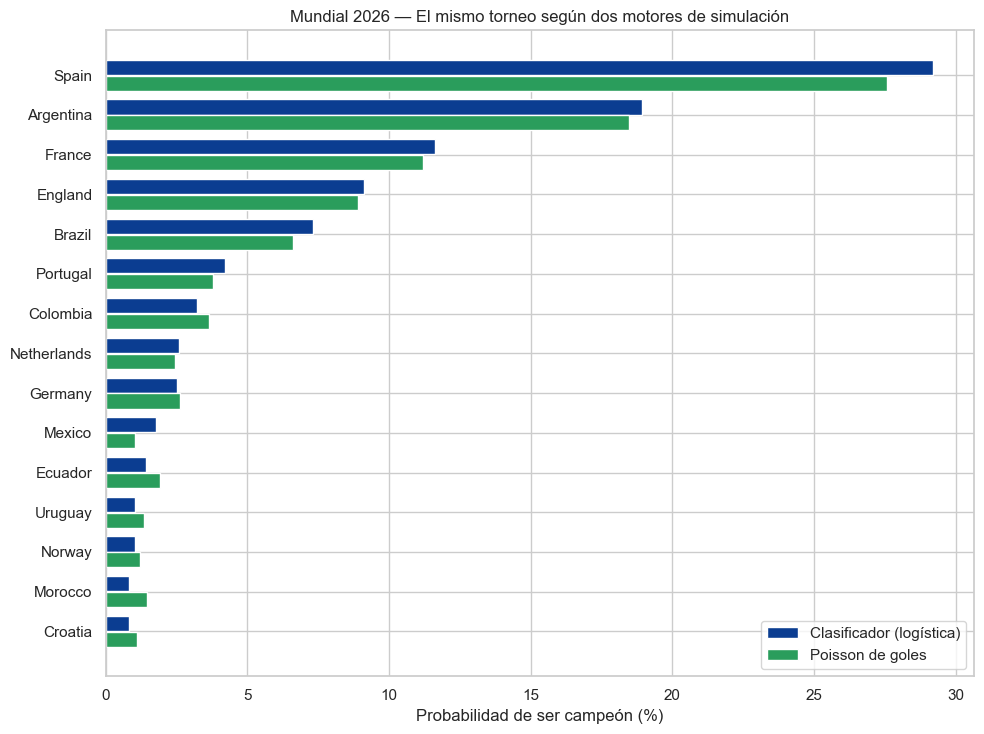

Mayores diferencias entre motores (P campeón):


,Selección,grupo,P_campeon_logit,P_campeon_poisson,dif (logit − poisson)
0,Spain,H,0.2918,0.2757,0.0161
1,Mexico,A,0.0179,0.0105,0.0074
2,Brazil,C,0.0732,0.0661,0.0071
3,Morocco,C,0.0084,0.0145,-0.0061
4,Ecuador,E,0.0141,0.0191,-0.0050
5,Japan,F,0.0077,0.0123,-0.0046
6,Argentina,J,0.1892,0.1847,0.0045
7,Colombia,K,0.0321,0.0363,-0.0042


In [26]:
from scipy.stats import spearmanr

cmp_ = res_mc[['Selección', 'grupo', 'P_campeon', 'P_semi']].merge(
    res_pois[['Selección', 'P_campeon', 'P_semi']], on='Selección', suffixes=('_logit', '_poisson'))
cmp_['dif (logit − poisson)'] = cmp_.P_campeon_logit - cmp_.P_campeon_poisson

pe_ = cmp_.P_campeon_logit.corr(cmp_.P_campeon_poisson)
sp_ = spearmanr(cmp_.P_campeon_logit, cmp_.P_campeon_poisson).statistic
print(f'Correlación de P(campeón) entre motores: Pearson {pe_:.3f} | Spearman (orden) {sp_:.3f}\n')

top = cmp_.sort_values('P_campeon_logit', ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7.5))
ypos = np.arange(len(top))
ax.barh(ypos + 0.2, top.P_campeon_logit * 100, height=0.38, color='#0b3d91', label='Clasificador (logística)')
ax.barh(ypos - 0.2, top.P_campeon_poisson * 100, height=0.38, color='#2a9d5c', label='Poisson de goles')
ax.set_yticks(ypos); ax.set_yticklabels(top['Selección'])
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 — El mismo torneo según dos motores de simulación')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print('Mayores diferencias entre motores (P campeón):')
dif = cmp_.reindex(cmp_['dif (logit − poisson)'].abs().sort_values(ascending=False).index).head(8)
display(dif[['Selección', 'grupo', 'P_campeon_logit', 'P_campeon_poisson', 'dif (logit − poisson)']]
        .round(4).reset_index(drop=True))

**Lectura.** Los dos motores cuentan esencialmente la **misma historia** — la correlación de
P(campeón) es altísima y el orden de favoritos se conserva. Es la versión "torneo completo" de lo que
§10 mostró partido a partido: dos familias de modelos distintas, alimentadas con las mismas 3
variables, convergen. Donde difieren, difieren por sus **supuestos**, no por la información:

- La Poisson se entrenó **sin localía** → los anfitriones (México, USA, Canadá) pierden el empuje que
  el clasificador sí les da en sus partidos.
- Con goles independientes, la Poisson reparte **menos empates** en grupos y concentra más
  probabilidad en los favoritos en cruces desparejos (las colas de la distribución).

Que el pronóstico del torneo sea robusto al cambio de motor es de las mejores noticias
metodológicas del trabajo: las probabilidades no dependen de una elección de modelo afortunada.

## 11 · El Mundial real: validación en vivo + cuadro de eliminatorias

El Mundial 2026 ya se juega. Esta sección hace dos cosas con los **resultados reales** (API pública de
ESPN), sin re-entrenar nada:

1. **Validación out-of-sample de verdad:** comparar la predicción **pre-torneo** del modelo contra el
   resultado real de cada partido de la **fase de grupos completa** (la prueba más honesta posible —
   datos que el modelo jamás vio).
2. **Cuadro de eliminatorias real:** ahora que la fase de grupos terminó, los cruces ya **no se simulan,
   se conocen**. Tomamos los 16 cruces reales de ESPN, los colocamos en el árbol oficial FIFA y
   simulamos **solo las eliminatorias** con el Elo ya actualizado por los resultados del Mundial.

In [27]:
# --- Resultados reales del Mundial desde ESPN (sin re-entrenar el modelo) ---
import sys
sys.path.insert(0, '../lab')
LIVE = True
try:
    import espn_live
    res_live = espn_live.traer_resultados()
    LIVE = len(res_live) >= 1
except Exception as e:
    LIVE = False
    print('ESPN no disponible ahora mismo (se omite la sección en vivo):', e)

if LIVE:
    from sklearn.metrics import log_loss
    grupos_live = res_live.iloc[:72]                       # los 72 de la fase de grupos
    P, y = [], []
    for r in grupos_live.itertuples(index=False):
        a, b = r.local, r.visita
        if a not in states.index or b not in states.index:
            continue
        p = prob_partido(a, b)                              # predicción PRE-torneo (Elo de junio)
        real = 2 if r.goles_local > r.goles_visita else (1 if r.goles_local == r.goles_visita else 0)
        P.append([p[2], p[1], p[0]]); y.append(real)
    P, y = np.array(P), np.array(y); n = len(y)
    base = np.tile([0.279, 0.275, 0.446], (n, 1))
    acc = float((P.argmax(1) == y).mean())
    ll_m = log_loss(y, P, labels=[0, 1, 2]); ll_b = log_loss(y, base, labels=[0, 1, 2])
    print(f'Fase de grupos jugada: {min(len(res_live), 72)}/72 partidos  ·  validados: {n}')
    print(f'  Acierto (1X2)      : {acc:.1%}')
    print(f'  Log-loss modelo    : {ll_m:.3f}   ({"MEJOR" if ll_m < ll_b else "peor"} que baseline {ll_b:.3f})')
    print(f'  P(empate) predicha : {P[:,1].mean():.1%}   vs   empates reales: {(y==1).mean():.1%}')


Fase de grupos jugada: 72/72 partidos  ·  validados: 72
  Acierto (1X2)      : 61.1%
  Log-loss modelo    : 0.873   (MEJOR que baseline 1.059)
  P(empate) predicha : 27.6%   vs   empates reales: 27.8%


**Lectura.** Sobre la fase de grupos completa el modelo rinde **en línea con su test histórico**
(log-loss ~0.85–0.88, acierto ~60%) y **le gana al baseline de frecuencias**, con la probabilidad de
empate bien calibrada. El arranque flojo de los primeros partidos (los Mundiales empiezan con muchos
empates y sorpresas — *efecto debut*) **revierte a la media** al acumular partidos: era varianza
esperable, no un sesgo. Por eso **no se re-entrena con estos 72 partidos** (sería sobreajustar a una
muestra mínima); lo correcto es alimentar al modelo con la realidad —Elo actualizado y bracket ya
definido— sin tocar su estructura.

In [28]:
# --- Cuadro de eliminatorias REAL: cruces de ESPN colocados en la plantilla FIFA ---
if LIVE and len(res_live) >= 72:
    from collections import Counter
    grupos_live = res_live.iloc[:72]

    # posiciones reales de cada grupo (pts -> dif. gol -> goles)
    def _orden_grupo(g):
        eqs = GRUPOS[g]; s = {t: dict(Pts=0, GF=0, GC=0) for t in eqs}
        for r in grupos_live.itertuples(index=False):
            if r.local in eqs and r.visita in eqs:
                a, b, ga, gb = r.local, r.visita, r.goles_local, r.goles_visita
                s[a]['GF'] += ga; s[a]['GC'] += gb; s[b]['GF'] += gb; s[b]['GC'] += ga
                if ga > gb: s[a]['Pts'] += 3
                elif gb > ga: s[b]['Pts'] += 3
                else: s[a]['Pts'] += 1; s[b]['Pts'] += 1
        return sorted(eqs, key=lambda t: (s[t]['Pts'], s[t]['GF'] - s[t]['GC'], s[t]['GF']), reverse=True)
    orden = {g: _orden_grupo(g) for g in GRUPOS}
    primeros = {g: o[0] for g, o in orden.items()}; segundos = {g: o[1] for g, o in orden.items()}

    # cruces reales de ESPN (correctos, incluida la asignación de terceros que hace FIFA por tabla)
    r32_espn = list(espn_live.bracket_eliminatorias()['R32'].values())

    # colocar cada cruce de ESPN en su llave por el equipo 1°/2° YA conocido (N de ESPN = nº FIFA - 72)
    def _conocido(slot):
        if isinstance(slot, tuple): return None
        return primeros[slot[1]] if slot[0] == '1' else segundos[slot[1]]
    R32d, usados = {}, set()
    for g, (sa, sb) in R32.items():
        known = [k for k in (_conocido(sa), _conocido(sb)) if k]
        i = next(j for j, m in enumerate(r32_espn)
                 if j not in usados and all(k in (m['home'], m['away']) for k in known))
        usados.add(i); R32d[g - 72] = (r32_espn[i]['home'], r32_espn[i]['away'])

    def _feed(g):
        if 73 <= g <= 88: return ('R32', g - 72)
        if 89 <= g <= 96: return ('R16', g - 88)
        if 97 <= g <= 100: return ('QF', g - 96)
        return ('SF', g - 100)
    R16d = {g - 88: (_feed(a), _feed(b)) for g, (a, b) in R16.items()}
    QFd = {g - 96: (_feed(a), _feed(b)) for g, (a, b) in QF.items()}
    SFd = {g - 100: (_feed(a), _feed(b)) for g, (a, b) in SF.items()}
    FINd = (_feed(FINAL_M[0]), _feed(FINAL_M[1]))

    # Elo actualizado por TODOS los resultados reales (K=60 estilo eloratings, con multiplicador de goleada)
    def _elo_up(ea, eb, ga, gb, k=60.0):
        we = 1 / (1 + 10 ** (-(ea - eb) / 400)); w = 1.0 if ga > gb else (0.0 if ga < gb else 0.5)
        gd = abs(ga - gb); mult = 1.0 if gd <= 1 else (1.5 if gd == 2 else (1.75 if gd == 3 else 1.75 + (gd - 3) / 8))
        d = k * mult * (w - we); return ea + d, eb - d
    states_pre = states.copy(); states_live = states.copy()
    for r in res_live.itertuples(index=False):
        a, b = r.local, r.visita
        if a in states_live.index and b in states_live.index:
            ea, eb = _elo_up(states_live.loc[a, 'elo'], states_live.loc[b, 'elo'], r.goles_local, r.goles_visita)
            states_live.loc[a, 'elo'], states_live.loc[b, 'elo'] = ea, eb
    globals()['states'] = states_live                      # prob_partido usará el Elo actualizado

    # KO ya jugados (cualquier ronda), fijados por el par de equipos — usa el ganador real de ESPN
    # (flag 'winner'), de modo que respeta los PENALES (un 1-1 queda fijado a quien realmente avanzó)
    ko = espn_live.ganadores_ko()

    rng = np.random.default_rng(SEED); _cache = {}
    def _padv(a, b):
        if (a, b) not in _cache:
            p = prob_partido(a, b); s = p[0] + p[2]; v = p[0] + p[1] * p[0] / s if s > 0 else 0.5
            _cache[(a, b)] = v; _cache[(b, a)] = 1 - v
        return _cache[(a, b)]
    def _jugar(a, b):
        f = ko.get(frozenset({a, b}))
        return f if f else (a if rng.random() < _padv(a, b) else b)

    NS = 20000; champ = Counter()
    for _ in range(NS):
        W = {'R32': {}, 'R16': {}, 'QF': {}, 'SF': {}}
        for nn, (a, b) in R32d.items(): W['R32'][nn] = _jugar(a, b)
        for rk, rd in (('R16', R16d), ('QF', QFd), ('SF', SFd)):
            for nn, (fa, fb) in rd.items(): W[rk][nn] = _jugar(W[fa[0]][fa[1]], W[fb[0]][fb[1]])
        champ[_jugar(W[FINd[0][0]][FINd[0][1]], W[FINd[1][0]][FINd[1][1]])] += 1

    globals()['states'] = states_pre                       # restaurar el Elo pre-torneo
    camp = (pd.DataFrame([{'Selección': t, 'P_campeon': c / NS} for t, c in champ.items()])
            .sort_values('P_campeon', ascending=False).reset_index(drop=True))
    camp.to_csv('../outputs/probabilidades_campeon_bracket_real.csv', index=False)
    print(f'Campeón segun el cuadro REAL ({NS:,} simulaciones de las eliminatorias):\n')
    print(camp.head(10).to_string(index=False, formatters={'P_campeon': '{:.1%}'.format}))
    print('\nGuardado: probabilidades_campeon_bracket_real.csv')
else:
    print('Aun no hay fase de grupos completa en ESPN: el cuadro real se llena cuando termine.')


Campeón segun el cuadro REAL (20,000 simulaciones de las eliminatorias):

Selección P_campeon
Argentina     27.4%
    Spain     21.8%
   France     21.6%
   Brazil      8.4%
  England      7.9%
 Colombia      3.1%
 Portugal      2.4%
  Morocco      2.0%
   Mexico      1.4%
   Norway      1.1%

Guardado: probabilidades_campeon_bracket_real.csv


**Lectura.** Con la fase de grupos ya definida, el pronóstico se **afila**: desaparece la
incertidumbre de "qué selecciones saldrían de cada grupo" y solo queda el azar de las eliminatorias,
con cada Elo ya movido por lo que pasó en el Mundial. Es la versión *condicionada a la realidad* del
pronóstico de §9 — misma metodología, mejores insumos. Nota: aquí los 8 terceros y sus llaves vienen
**tal cual de ESPN** (no del emparejamiento aproximado de §9.2), de modo que el cuadro coincide
exactamente con el oficial.

## 12 · Conclusiones y limitaciones

**Metodología:**
- **Sin fuga en dos frentes:** variables point-in-time/walk-forward por construcción **y validación
  temporal en todo** (selección de variables, comparación de modelos y test final 2025–26). Es la
  diferencia entre *creer* que el modelo funciona y *saberlo*.
- **Selección de variables data-driven:** de 11 candidatas sobreviven **3** (`elo_diff`, `h2h_diff`,
  `squad_value_diff`) por VIF + forward + significancia. El set de 3 **supera tanto a solo-Elo como a
  las 11 completas**: la selección paga, las demás variables meten ruido. Y el **Lasso sobre las 11
  converge a las mismas 3 variables** (§8) — un mecanismo de selección independiente valida el set final.
- La definición del h2h también se desafió (§3.1): restringirlo a la última década **empeora** (pérdida
  de cobertura) y las ventanas por nº de duelos empatan con el completo — se mantiene el h2h desde 1872.
- El **tipo de competición** se analizó (§6c): los amistosos son intrínsecamente menos predecibles
  (log-loss ~0.92 vs ~0.78 en partidos competitivos). De ahí un corolario que cambia la lectura del
  proyecto — **el pronóstico del Mundial es mejor que la métrica titular**: el 0.85 global está
  arrastrado por amistosos que no nos importan; en partidos en serio (lo que es el Mundial) el modelo
  rinde ~0.78. El motor del torneo se entrena ponderando por K-factor (Mundial 3× un amistoso).
- Clasificación **multinomial (V/E/D)** con el empate modelado y evaluado con **RPS** y log-loss; la
  probabilidad de empate sale bien calibrada (forzar empates por `class_weight` la empeora).
- Comparación de **14 modelos** (lineales con y sin selección, Lasso/Ridge/Elastic Net, ordinal con
  enlaces logit y probit — empatan: el enlace es irrelevante y quedó comprobado —, SVM, red neuronal,
  Random Forest/Gradient Boosting/XGBoost) bajo idéntico protocolo y con hiperparámetros elegidos por
  el mismo CV temporal, + **Poisson de goles** y su **ensamble** como contraste de familia —
  coinciden → robustez.
- Simulación con **simetrización de localía** (cancha neutral), anfitriones con localía en todas sus
  rondas, marcadores Poisson **condicionados** al clasificador, terceros bien rankeados y bracket
  oficial FIFA de 48 — y el torneo completo **re-simulado con un segundo motor** (Poisson pura, §10.1):
  ambos Mundiales coinciden (§10.2), el pronóstico no depende de la elección de modelo.

**Hallazgo central:** el **Elo concentra la mayor parte de la señal** — es un acumulador histórico de
resultados y forma, así que los promedios móviles recientes resultan redundantes. Lo que sí agrega
sobre él: la **historia particular del cruce** (`h2h_diff`, rivalidades que el rating general no ve) y
el **valor de la plantilla** (talento que aún no se tradujo a resultados). La versión v4 con otros
datos llegó a una conclusión estructuralmente igual: *fuerza + plantilla + un matiz* — buena señal de
estabilidad metodológica.

**Limitaciones:** el estado de los equipos queda **congelado al corte de junio 2026** (sin lesiones,
convocatorias ni la dinámica del torneo); la localía de los anfitriones se aproxima con la ventaja
promedio del dataset; el h2h de cruces sin historial se asume neutro (0); los 8 terceros se asignan
con un emparejamiento válido, no con la tabla exacta FIFA (efecto mínimo); y el empate sigue siendo la
clase más difícil — problema abierto en la literatura.

**Ideas a futuro:** actualizar `team_states` partido a partido *dentro* del torneo y re-simular tras
cada jornada; Poisson bivariada (correlación de goles); variables de convocatoria (minutos en ligas
top, edad media del XI).

*Proyecto personal — hecho con datos, rigor y fútbol.* ⚽